<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.975 · Deep Learning · PAC3</p>
<p style="margin: 0; text-align:right;">2025-2 · Màster universitari en Ciència de dades (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudis d'Informàtica, Multimèdia i Telecomunicació</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PAC 3: Transformers amb PyTorch


<p><u>Consideracions generals</u>:</p>

<ul>
  <li>Aquesta PAC s'ha de fer de manera <strong>estrictament individual</strong>. Qualsevol indici de còpia serà penalitzat amb un suspens (D) per a totes les parts implicades i la possible avaluació negativa de la totalitat de l'assignatura.</li>
  <li>És necessari que l'estudiant indiqui <strong>totes les fonts</strong> que ha utilitzat per a la realització de la PAC. En cas contrari, es considerarà que l'alumne ha comès plagi, sent penalitzat amb un suspens (D) i la possible avaluació negativa de la totalitat de l'assignatura.</li>
  <li>Si s'utilitza qualsevol <strong>IA generativa</strong> en la resolució de la PAC <strong>s'ha de referenciar</strong> en aquelles seccions on s'ha utilitzat, com qualsevol altra font.</li>
</ul>

<p><u>Format del lliurament</u>:</p>

<ul>
  <li>Alguns exercicis poden suposar diversos minuts d'execució, de manera que el lliurament s'ha de fer en format <strong>Notebook</strong> i en format <strong>html</strong>, on es vegi el codi, els resultats i els comentaris de cada exercici. Podeu exportar el quadern a HTML a Jupyter Notebook des del menú File $\to$ Download as $\to$ HTML.</li>
  <li>Hi ha un tipus especial de cel·la per allotjar el text. Aquest tipus de cel·les serà molt útil per respondre a les diferents preguntes teòriques plantejades al llarg de l'activitat. Per canviar el tipus de cel·la a aquest tipus, al menú: Cell $\to$ Cell Type $\to$ Markdown.</li>
</ul>

<h2>0. Context i càrrega de biblioteques</h2>

<p>En aquest exercici pràctic ens inspirem en l'article <i>“Text Classification: Neural Networks vs Machine Learning Models vs Pre-trained Models”</i> (<a href="https://arxiv.org/pdf/2412.21022">https://arxiv.org/pdf/2412.21022</a>). En realitat, en aquest exercici treballarem amb <strong>generació de text</strong> (<i>text generation</i>), però l'article ens serà útil per entendre com comparar models, tipus de gràfiques o estudis d'ablació (<i>ablation studies</i>) que es poden aplicar. L'objectiu del treball és explorar i entendre de manera pràctica com diferents tipus de xarxes neuronals seqüencials poden abordar la tasca de classificació de text.</p>

<h3>Consideracions sobre complexitat computacional i ús de GPU en la PAC:</h3>

<p><strong>Atenció -> Executar correctament aquesta PAC requereix temps i organització.</strong></p>

<p>Treballarem amb <i>transformers</i>, arquitectures grans, etc. Serà necessària la utilització de <strong>GPU</strong> per accelerar els càlculs i, a més, el temps de computació pot ser elevat. L'execució final de tot l'exercici pot durar fàcilment diverses hores en GPU. Per això, aquí tens alguns consells fonamentals per facilitar la teva feina:</p>

<ul>
    <li>Comença programant i depurant (<i>debugging</i>) el teu exercici amb subconjunts petits que puguis executar en minuts, fins i tot en local amb CPU. També pots considerar anar fent la PAC per parts sense necessitat d'executar-ho tot de cop. Quan el teu codi estigui preparat, escala l'exercici.</li>
    <li>Si utilitzes plataformes com <strong>Kaggle</strong> i <strong>Colab</strong>, tingues en compte les seves limitacions de temps i organitza't d'acord amb això.</li>
    <li>Kaggle acostuma a ser més estable que Colab.</li>
    <li>Si utilitzes Colab Pro, tingues en compte que si l'enllaces amb Kaggle, també tindràs més hores de còmput a Kaggle: <a href="https://www.kaggle.com/blog/level-up-your-compute-more-gpu-hours-on-kaggle-wit">Enllaç explicatiu</a>.</li>
    <li>Comença la PAC aviat, perquè tinguis temps d'executar-la i comentar les teves conclusions abans de lliurar-la.</li>
    <li>A l'hora de triar les GPUs, tingues en compte quina és més ràpida (p. ex., <a href="https://www.topcpu.net/es/gpu-c/tesla-p100-pcie-16-gb-vs-tesla-t4">comparativa Tesla P100 vs T4</a>).</li>
    <li>Per molt que tinguis accés a 2xGPU, si el teu codi no està adaptat a <i>multiGPU</i>, simplement tindràs una GPU sense utilitzar.</li>
    <li>Et sembla llarg? Dona un cop d'ull als temps d'entrenament dels LLM (és interessant el cas de Megatron-Turing): <a href="https://en.wikipedia.org/wiki/List_of_large_language_models">Llista dels LLM a Wikipedia</a>.</li>
</ul>

In [1]:
# Instal·la les dependències necessàries en colab (opcional)
from IPython import get_ipython
import os

ip = get_ipython()
# Munta la unitat de google drive i accedeix a la carpeta de treball.
# Instal·la les dependències necessàries només si s'està executant en colab.
if os.getenv("COLAB_RELEASE_TAG"):
    from google.colab import drive

    drive.mount("/content/drive")
    ip.run_line_magic("cd", '"/content/drive/MyDrive/Colab Notebooks/Activity_3"')
    # instal·la les dependències
    ip.run_line_magic(
        "pip", "install evaluate"
    )

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/Activity_3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [2]:
import math
import copy
import random
import time
import os
import copy
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import AxesImage
import re
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from datasets import load_dataset
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
)

import evaluate

metric = evaluate.load("accuracy")

from tqdm import tqdm
from tabulate import tabulate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

# Seeds de Python i NumPy
random.seed(SEED)
np.random.seed(SEED)

# Seeds de PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Configuració de PyTorch per a determinisme (més lent però garanteix reproducibilitat)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Versió de Python
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"SEED = {SEED}")
print(f"Device: {DEVICE}\n")
if DEVICE.type == "cuda":
    !nvidia-smi

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.10.0+cu128
NumPy version: 2.0.2
SEED = 42
Device: cuda

Sat May  9 08:45:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default 

<h2>1. Baseline. RNN vs Transformers</h2>

<p>Començarem comparant la generació de text (<i>text generation</i>); en concret, implementarem des de zero dos models senzills per a aquesta tasca: un model <strong>LSTM</strong> i un model basat en <strong>transformers</strong>, per finalment comparar-los entre ells.</p>


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

Abans d'entrenar models de llenguatge, necessitem convertir el text en unitats bàsiques que puguem utilitzar. Hi ha diversos passos per preparar un text per a l'entrenament d'un model de generació de llenguatge:
<ol>
    <li><strong>Tokenització:</strong> Aquestes unitats bàsiques poden ser de tipus molt diferents: paraules, BPE, caràcters, etc. En aquesta primera part utilitzarem paraules. L'objectiu és separar el text en unitats bàsiques (<a href="https://www.traceloop.com/blog/a-comprehensive-guide-to-tokenizing-text-for-llms">guia sobre tokenització</a>).</li>
    <li><strong>Codificació de tokens a números.</strong></li>
    <li><strong>Padding i seqüències fixes:</strong> Les seqüències d'entrenament han de tenir la mateixa longitud. Aquí utilitzarem una longitud de 50. El model intentarà predir l'última paraula basant-se en les anteriors. Si la seqüència és més curta, simplement s'omple amb <i>padding</i>.</li>
</ol>

<strong>Exercici 1. Preparació de les dades [1 pt.].</strong>

<ul>
    <li>Carregar el dataset <code>wikitext-2-raw-v1</code> des del repositori de Hugging Face: <a href="https://huggingface.co/datasets/Salesforce/wikitext">https://huggingface.co/datasets/Salesforce/wikitext</a></li>
    <li>Preparació de les dades de <i>train</i>, <i>validation</i> i <i>test</i> de la següent forma:
        <ul>
            <li>Tokenitza el text.</li>
            <li>Crea seqüències de fins a 50 paraules més la paraula objectiu (la 51). Amb cada text, crea el màxim nombre de seqüències possibles.</li>
            <li>Pot ser que entrenar amb totes les seqüències sigui excessiu. Tria de manera adequada un subconjunt d'aquestes.</li>
        </ul>
    </li>
    <li>Mostra en una taula les dades que hi havia al principi, el nombre de seqüències totals generades i amb les quals t'has quedat finalment. La taula ha d'estar ben formatada amb línies.</li>
    <li>Imprimeix en pantalla 10 seqüències de cadascun dels teus subconjunts finals.</li>
</ul>
</div>


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
</div>

In [3]:
# ============================================================================
# EXERCICI 1: CREACIÓ DE SEQÜÈNCIES I VOCABULARI A PARTIR DE TEXTOS
# ============================================================================
SEQ_LEN = 50  # Longitud de les seqüències d'entrada (sense incloure el target)
REDUCED_DATASETS = False  # Canvia a False per usar tot el dataset (pot ser lent)
TRAIN_KEEP = 5000  # Nombre de seqüències a mantenir en el subconjunt d'entrenament (si REDUCED_DATASETS és True)
VAL_KEEP = 500  # Nombre de seqüències a mantenir en el subconjunt de validació (si REDUCED_DATASETS és True)
TEST_KEEP = 500  # Nombre de seqüències a mantenir en el subconjunt de test (si REDUCED_DATASETS és True)
N_SEQS_TO_SHOW = 10  # Nombre de seqüències a mostrar per cada subconjunt
PAD_TOKEN = "<PAD>"  # Token de padding per seqüències més curtes que SEQ_LEN
UNK_TOKEN = "<UNK>"  # Token per paraules fora del vocabulari
NUM_STR = "0"  # Token per números (opcional)
MAX_VOCAB = 10_000  # Nombre màxim de paraules al vocabulari (sense incloure PAD i UNK)
MIN_FREQ = 5  # Nombre mínim de vegades que una paraula ha d'aparèixer per ser inclosa al vocabulari


def simple_tokenize(text: str, num_str: str = NUM_STR) -> list[str]:
    """
    Tokenització per paraules.
    Parameters:
        text (str): cadena de text a tokenitzar
        num_str (str, optional): text per als números
    Returns:
        list[str]: llista de tokens resultants de la tokenització
    """
    # Converteix a minúscules
    text = text.lower()
    # Substitueix "it 's", "she 's", "he 's" i "they 're" per les seves formes completes
    if " it 's " in text:
        text = re.sub(r" it 's ", " it is ", text)
    if " she 's " in text:
        text = re.sub(r" she 's ", " she is ", text)
    if " he 's " in text:
        text = re.sub(r" he 's ", " he is ", text)
    if " they 're " in text:
        text = re.sub(r" they 're ", " they are ", text)
    # Substitueix números per un únic valor incloent alguns números romans
    text = re.sub(r"\b\d+\b", num_str, text)
    text = re.sub(r"\b(ii|iii|iv|v)\b", num_str, text)
    # Substitueix signes de puntuació per espais
    text = re.sub(r"[^\w\s]", " ", text)
    # Normalitza espais múltiples a un sol espai
    text = re.sub(r"\s+", " ", text)
    # Retorna una llista de tokens
    return text.strip().split()


def encode_tokens(tokens: list[str], vocab: dict[str, int]) -> list[int]:
    """
    Converteix una llista de tokens a una llista d'identificadors segons un vocabulari.
    Parameters:
        tokens (list[str]): llista de tokens a convertir
        vocab (dict[str, int]): diccionari que mapeja tokens a identificadors
    Returns:
        list[int]: llista d'identificadors corresponents als tokens, amb UNK_TOKEN per a tokens no trobats
    """
    return [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokens]


def build_sequences_from_texts(
    texts: list[str], vocab: dict[str, int], max_seq_len: int = SEQ_LEN
) -> list[tuple[list[int], int]]:
    """
    Construeix seqüències d'entrada i targets a partir de textos, utilitzant una finestra lliscant.
    Parameters:
        texts (list[str]): llista de cadenes de text
        vocab (dict[str, int]): diccionari que mapeja tokens a identificadors
        max_seq_len (int, optional): longitud màxima de les seqüències d'entrada (sense incloure el target)
    Returns:
        list[tuple[list[int], int]]: llista de tuples (seqüència d'entrada, target) on seqüència d'entrada és una llista d'identificadors de tokens i target és l'identificador del token següent a la seqüència.
    """
    seqs = []
    for t in texts:
        tokens = simple_tokenize(t)
        if len(tokens) <= max_seq_len:
            continue
        ids = encode_tokens(tokens, vocab)
        # sliding window
        for i in range(len(ids) - max_seq_len):
            x = ids[i : i + max_seq_len]
            y = ids[i + max_seq_len]
            seqs.append((x, y))
    return seqs


def subsample(
    seqs: list[tuple[list[str], str]], max_n: int
) -> list[tuple[list[str], str]]:
    """
    Submostreig aleatori de seqüències per limitar el nombre total.
    Parameters:
        seqs (list[tuple[list[str], str]]): llista de tuples (seqüència, target)
        max_n (int): nombre màxim de seqüències a retornar
    Returns:
        list[tuple[list[str], str]]: llista de tuples (seqüència, target) amb un màxim de `max_n` elements, seleccionats aleatòriament si la llista original és més llarga.
    """
    seqs_length = len(seqs)
    if seqs_length <= max_n:
        return seqs
    seqs_start = random.randint(0, seqs_length - max_n)
    return seqs[seqs_start : seqs_start + max_n]


def print_texts(name: str, texts: list[str], n: int = N_SEQS_TO_SHOW) -> None:
    """
    Imprimeix les primeres `n` cadenes de text per a una divisió.
    Parameters:
        name (str): nom de la divisió (per exemple, "Train", "Validation", "Test")
        texts (list[str]): llista de cadenes de text
        n (int, optional): nombre de cadenes a mostrar
    """
    print(f"\n=== TEXTS / {name} ===")
    for i in range(min(n, len(texts))):
        print(f"{i+1}. {texts[i]}")


def print_seqs(
    name: str,
    data: list[tuple[list[int], int]],
    ivocab: dict[int, str],
    n: int = N_SEQS_TO_SHOW,
) -> None:
    """
    Imprimeix les primeres `n` seqüències i els seus targets per a una divisió.
    Parameters:
        name (str): nom de la divisió (per exemple, "Train", "Validation", "Test")
        data (list[tuple[list[int], int]]): llista de tuples (seqüència d'entrada, target) on seqüència d'entrada és una llista d'identificadors de tokens i target és l'identificador del token següent a la seqüència.
        ivocab (dict[int, str]): diccionari que mapeja identificadors a tokens, per a mostrar les seqüències de manera més llegible (opcional)
        n (int, optional): nombre de seqüències a mostrar
    """

    def id_to_token(x):
        try:
            idx = int(x)
        except Exception:
            return str(x)
        return ivocab.get(idx, str(idx)) if "ivocab" in globals() else str(idx)

    print(f"\n=== SEQUENCES / {name} ===")
    for i in range(min(n, len(data))):
        seq, target = data[i]
        seq_display = [id_to_token(t) for t in seq]
        target_display = id_to_token(target)
        print(f"{i+1}. [{', '.join(seq_display)}] -> {target_display}")


def build_vocab(
    texts: list[str],
    max_vocab: int = MAX_VOCAB,
    min_freq: int = MIN_FREQ,
    pad_token: str = PAD_TOKEN,
    unk_token: str = UNK_TOKEN,
) -> dict[str, int]:
    """
    Construeix un vocabulari a partir d'una llista de textos, limitant el nombre de paraules i la freqüència mínima.
    Parameters:
        texts (list[str]): llista de cadenes de text
        max_vocab (int, optional): nombre màxim de paraules al vocabulari (sense incloure PAD i UNK)
        min_freq (int, optional): nombre mínim de vegades que una paraula ha d'aparèixer per ser inclosa al vocabulari
        pad_token (str, optional): token de padding per seqüències més curtes que SEQ_LEN
        unk_token (str, optional): token per paraules fora del vocabulari
    Returns:
        dict[str, int]: diccionari que mapeja tokens a identificadors, incloent PAD_TOKEN i UNK_TOKEN
    """
    counter = Counter()
    for t in texts:
        tokens = simple_tokenize(t)
        counter.update(tokens)
    vocab = {pad_token: 0, unk_token: 1}
    for w, c in counter.items():
        if c >= min_freq and len(vocab):
            vocab[w] = len(vocab)
        if len(vocab) >= max_vocab:
            break
    return vocab

In [4]:
print("=" * 70)
print("EXERCICI 1: CREACIÓ DE SEQÜÈNCIES I VOCABULARI A PARTIR DE TEXTOS")
print("=" * 70)

# Carregar dataset
raw_ds = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", cache_dir="./data")
train_texts = [x["text"] for x in raw_ds["train"]]
val_texts = [x["text"] for x in raw_ds["validation"]]
test_texts = [x["text"] for x in raw_ds["test"]]

# Construir vocabulari a partir de train
vocab = build_vocab(train_texts)
ivocab = {i: w for w, i in vocab.items()}
vocab_size = len(vocab)
print("Mida vocabulari:", vocab_size)

# Crear seqüències de longitud SEQ_LEN + target
train_seqs_all = build_sequences_from_texts(train_texts, vocab)
val_seqs_all = build_sequences_from_texts(val_texts, vocab)
test_seqs_all = build_sequences_from_texts(test_texts, vocab)

# Submostreig per reduir el nombre de seqüències si REDUCED_DATASETS és True
if REDUCED_DATASETS:
    train_seqs = subsample(train_seqs_all, TRAIN_KEEP)
    val_seqs = subsample(val_seqs_all, VAL_KEEP)
    test_seqs = subsample(test_seqs_all, TEST_KEEP)
else:
    train_seqs = train_seqs_all
    val_seqs = val_seqs_all
    test_seqs = test_seqs_all
    test_final = test_seqs

# Taula resum amb el nombre de seqüències totals i finals per a cada subconjunt
table = [
    ["Train", len(train_seqs_all), len(train_seqs)],
    ["Validation", len(val_seqs_all), len(val_seqs)],
    ["Test", len(test_seqs_all), len(test_seqs)],
]
print(
    tabulate(
        table,
        headers=["Split", "Seqüències totals", "Seqüències finals"],
        tablefmt="grid",
    )
)

print_texts("TRAIN", train_texts)
print_seqs("TRAIN", train_seqs, ivocab)

print_texts("VALIDATION", val_texts)
print_seqs("VALIDATION", val_seqs, ivocab)

print_texts("TEST", test_texts)
print_seqs("TEST", test_seqs, ivocab)

print(f"\nMida vocabulari (incloent PAD/UNK): {len(vocab)}")

EXERCICI 1: CREACIÓ DE SEQÜÈNCIES I VOCABULARI A PARTIR DE TEXTOS


README.md: 0.00B [00:00, ?B/s]

Mida vocabulari: 10000
+------------+---------------------+---------------------+
| Split      |   Seqüències totals |   Seqüències finals |
+============+=====================+=====================+
| Train      |              992596 |              992596 |
+------------+---------------------+---------------------+
| Validation |              103322 |              103322 |
+------------+---------------------+---------------------+
| Test       |              115478 |              115478 |
+------------+---------------------+---------------------+

=== TEXTS / TRAIN ===
1. 
2.  = Valkyria Chronicles III = 

3. 
4.  Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing th

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 2. Entrenament LSTM vs. Transformer [2 pts.].</strong>

- En aquesta part, munta dos models senzills: un basat en <strong>LSTM</strong> i un altre en <strong>Transformer</strong> amb dos caps d'atenció (<i>attention heads</i>). Alguns requisits són:
  <ul>
    <li>El total de paràmetres entrenables de cadascun d'ells ha d'estar entre els <strong>5 i els 6 milions</strong> de paràmetres.</li>
    <li>La idea és que ambdós models siguin comparables, així que sigues tan consistent com sigui possible entre les dues arquitectures. Per exemple: un no pot tenir 15 capes i l'altre només 1.</li>
    <li>La resta de paràmetres és lliure, però has d'intentar evitar l'<i>overfitting</i> introduint regularitzacions, considerant el <i>lr</i> (taxa d'aprenentatge), el nombre d'èpoques, etc.</li>
  </ul>

Es demana:
<ul>
    <li>Construir ambdues arquitectures i entrenar els models. Durant l'entrenament, a cada època, genera una frase de 10 paraules que comenci amb <strong>"Artificial intelligence is"</strong>. L'objectiu és que observis com va millorant la capacitat de generació del model (0,5 p).</li>
    <li>Mostrar corbes de <i>train loss</i>, <i>validation loss</i> i <i>accuracy validation</i> comparant ambdós models. Les gràfiques han de ser llegibles, informatives i clares. En cas contrari, es consideraran incorrectes (0,5 p).</li>
    <li>Triar d'ambdues arquitectures el model amb menor <i>loss</i> en validació i mostrar en una taula formatada els valors de <i>accuracy</i> sobre test i sobre validació del millor model (0,5 p).</li>
    <li>Explicar en dues línies les teves conclusions principals en comparar ambdues arquitectures en aquest problema (0,5 p).</li>
</ul>

Consideracions:
<ul>
    <li>Probablement hauràs d'executar l'entrenament diverses vegades per ajustar els paràmetres, escalar les dades o el nombre d'èpoques.</li>
    <li>Abans de realitzar aquest exercici, és recomanable llegir l'enunciat dels següents exercicis, ja que hauràs de conservar alguns <strong>checkpoints</strong> d'aquest entrenament per ser utilitzats després.</li>
</ul>
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
</div>

In [5]:
# ============================================================================
# EXERCICI 2: PREDICCIÓ DE LA SEGÜENT PARAULA AMB LSTM I TRANSFORMER
# ============================================================================

BATCH_SIZE = 64
EPOCHS = 15  # Més èpoques, però amb early stopping protegirem contra overfitting
LR = 5e-4  # Taxa d'aprenentatge més baixa per a convergència més estable (1e-3 era massa alta)
PATIENCE = 7  # Major paciència per explorar millors solucions (5 era massa agressiu)
WEIGHT_DECAY = 1e-4  # Regularització L2 per penalitzar pesos grans
TRANS_NHEAD = 2  # Nombre de caps d'atenció al Transformer (2 caps per mantenir el nombre de paràmetres dins del rang)
TRANS_EMB_DIM = 192  # Dimensió d'embeddings al Transformer (igual que LSTM per mantenir paràmetres similars)
TRANS_LAYERS = 4  # Nombre de capes del Transformer (4 per mantenir el nombre de paràmetres dins del rang)
TRANS_FF_DIM = 512  # Dimensió de la capa feedforward al Transformer (512 per mantenir el nombre de paràmetres dins del rang)
TRANS_DROPOUT = (
    0.4  # Dropout per a regularització (0.4 per evitar overfitting en un dataset petit)
)
PROMPT = ["artificial", "intelligence", "is"]


class LMSeqDataset(Dataset):
    """
    Dataset per a seqüències de text. Cada element és una tupla (seqüència d'entrada, target).
    Parameters:
        seqs: llista de tuples (seqüència, target) on:
            - seqüència d'entrada: llista d'identificadors de vocabulari (ints) de longitud SEQ_LEN
            - target: identificador de vocabulari (int) corresponent a la paraula següent a la seqüència d'entrada
    El dataset assumeix que les seqüències ja han estat processades i codificades com a llistes d'identificadors de vocabulari (ints). No realitza cap tipus de tokenització o codificació, només retorna els tensors corresponents a les seqüències i els targets. El padding i el truncament de seqüències s'han de realitzar abans de crear el dataset, i les seqüències han d'estar codificades com a llistes d'identificadors de vocabulari (ints) que corresponen a les paraules del vocabulari. Aquest dataset és específic per a tasques de modelatge de llenguatge on l'objectiu és predir la següent paraula donada una seqüència d'entrada. No realitza cap tipus de processament addicional, com ara augmentació de dades o manipulació de seqüències, i assumeix que les dades d'entrada ja estan preparades en el format adequat per a l'entrenament del model.
    """

    def __init__(self, seqs):
        self.seqs = seqs

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        x, y = self.seqs[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


class LSTMModel(nn.Module):
    """
    Model de llenguatge basat en LSTM.
    Parameters:
        vocab_size (int): mida del vocabulari (nombre de paraules diferents)
        emb_dim (int): dimensió dels embeddings de paraules
        hidden_dim (int): dimensió de les capes ocultes de l'LSTM
        num_layers (int): nombre de capes de l'LSTM
        dropout (float): taxa de dropout per a regularització
        pad_idx (int): índex del token de padding al vocabulari (per a ignorar-lo en els embeddings)
    """

    def __init__(
        self,
        vocab_size,
        emb_dim=192,
        hidden_dim=256,
        num_layers=2,
        dropout=0.4,
        pad_idx=0,
    ):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        emb = self.emb(x)
        out, _ = self.lstm(emb)
        h_last = self.dropout(out[:, -1, :])
        logits = self.fc(h_last)
        return logits


class TransformerModel(nn.Module):
    def __init__(
        self,
        vocab_size,
        emb_dim=TRANS_EMB_DIM,
        nhead=TRANS_NHEAD,
        num_layers=TRANS_LAYERS,
        dim_feedforward=TRANS_FF_DIM,
        dropout=TRANS_DROPOUT,
        max_len=SEQ_LEN,
        pad_idx=0,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        # x: (B, T)
        B, T = x.size()
        pos = torch.arange(0, T, device=x.device).unsqueeze(0).expand(B, T)
        emb = self.embedding(x) + self.pos_emb(pos)  # (B, T, E)
        out = self.encoder(emb)  # (B, T, E)
        out = self.dropout(out)
        last = out[:, -1, :]  # (B, E)
        logits = self.fc(last)  # (B, V)
        return logits


def count_trainable_params(model: nn.Module) -> int:
    """
    Compta el nombre de paràmetres entrenables d'un model.
    Parameters:
        model (nn.Module): model de PyTorch del qual es vol comptar els paràmetres entrenables
    Returns:
        int: nombre total de paràmetres que requereixen gradients (entrenables) en el model.
    """
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def evaluate_model(
    model: nn.Module, loader: DataLoader, criterion: nn.Module
) -> tuple[float, float]:
    """
    Avalua el model en un conjunt de dades i calcula la pèrdua mitjana i l'accuracy.
    Parameters:
        model (nn.Module): model de PyTorch a avaluar
        loader (DataLoader): DataLoader que proporciona les dades d'avaluació
        criterion: funció de pèrdua per calcular la pèrdua mitjana
    Returns:
        tuple: (pèrdua mitjana, accuracy) on:
            - pèrdua mitjana: valor escalar de la pèrdua mitjana sobre el conjunt d'avaluació
            - accuracy: proporció de prediccions correctes sobre el conjunt d'avaluació (valor entre 0 i 1)
    """
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == y).sum().item()
            total += x.size(0)

    return total_loss / total, total_correct / total


def generate(
    model: nn.Module,
    prompt_tokens: list[str] = PROMPT,
    num_words: int = 10,
    sequence_length: int = SEQ_LEN,
    unk_idx: int = vocab[UNK_TOKEN],
    pad_idx: int = vocab[PAD_TOKEN],
):
    """
    Genera text a partir d'un prompt inicial, afegint paraules una a una segons les prediccions del model.
    Parameters:
        model (nn.Module): model de llenguatge entrenat que accepta seqüències d'entrada i retorna logits per al següent token
        prompt_tokens (list[str]): llista de tokens inicials (com a cadenes) que serveixen com a prompt per a la generació
        num_words (int, optional): nombre de paraules a generar després del prompt
        sequence_length (int, optional): longitud màxima de les seqüències d'entrada que el model pot processar (sense incloure el target)
        unk_idx (int, optional): índex del token UNK al vocabulari (per assignar probabilitat zero a paraules fora del vocabulari)
        pad_idx (int, optional): índex del token PAD al vocabulari (per assignar probabilitat zero al padding)
    Returns:
        str: text generat que comença amb el prompt i segueix amb les paraules generades pel model
    """
    model.eval()
    tokens = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in prompt_tokens]

    for _ in range(num_words):
        # agafem les últimes MAX_SEQ_LEN paraules (padding si cal)
        ctx = tokens[-sequence_length:]
        if len(ctx) < sequence_length:
            ctx = [vocab[PAD_TOKEN]] * (sequence_length - len(ctx)) + ctx
        x = torch.tensor(ctx, dtype=torch.long, device=DEVICE).unsqueeze(0)
        logits = model(x).squeeze(0)
        logits[unk_idx] = float("-inf")
        logits[pad_idx] = float("-inf")
        next_id = logits.argmax(dim=-1).item()
        tokens.append(next_id)
    return " ".join(prompt_tokens + [ivocab[t] for t in tokens[len(prompt_tokens) :]])


def train_model(
    model: nn.Module,
    model_name: str,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    lr: float,
    ckpt_prefix: str,
) -> dict[str, list[float]]:
    """
    Entrena un model de llenguatge i guarda checkpoints durant l'entrenament.
    Parameters:
        model (nn.Module): model de llenguatge a entrenar
        model_name (str): nom del model (per a mostrar en els logs)
        train_loader (DataLoader): DataLoader que proporciona les dades d'entrenament
        val_loader (DataLoader): DataLoader que proporciona les dades de validació
        epochs (int): nombre màxim d'èpoques per entrenar el model
        lr (float): taxa d'aprenentatge per a l'optimitzador
        ckpt_prefix (str): prefix per als noms dels checkpoints guardats durant l'entrenament
    Returns:
        dict[str, list[float]]: diccionari amb les llistes de pèrdues d'entrenament, pèrdues de validació i accuracies de validació per cada època, amb les següents claus:
            - "train_loss": llista de pèrdues mitjanes d'entrenament per cada època
            - "val_loss": llista de pèrdues mitjanes de validació per cada època
            - "val_acc": llista d'accuracies de validació per cada època (valors entre 0 i 1)
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0

        pbar = tqdm(train_loader, desc=f"{model_name} - Epoca {epoch}/{epochs}")
        for x, y in pbar:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            total += x.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        # Avaluació en validació
        train_loss = running_loss / total
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Generació de text de mostra
        gen_text = generate(model)
        print(f"\n[{model_name}] Epoca {epoch}/{epochs}")
        print(
            f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
        )
        print(f"Generated: {gen_text}\n")

        # Checkpoint
        ckpt = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": val_loss,
            "val_acc": val_acc,
            "vocab_size": vocab_size,
            "seq_len": SEQ_LEN,
        }

        if epoch == 1:
            torch.save(ckpt, f"checkpoints/{ckpt_prefix}_ep1.pt")

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(ckpt, f"checkpoints/{ckpt_prefix}_best.pt")
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(
                    f"[{model_name}] Early stopping activat a l'època {epoch}/{epochs} (patience={PATIENCE})"
                )
                break

    # Checkpoint final
    final_ckpt = {
        "epoch": epochs,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "val_loss": history["val_loss"][-1],
        "val_acc": history["val_acc"][-1],
        "vocab_size": vocab_size,
        "seq_len": SEQ_LEN,
    }
    torch.save(final_ckpt, f"checkpoints/{ckpt_prefix}_final.pt")

    return history

EXERCICI 2: PREDICCIÓ DE LA SEGÜENT PARAULA AMB LSTM I TRANSFORMER
Paràmetres entrenables LSTM: 5,477,136
Paràmetres entrenables Transformer (2 caps): 5,244,816
Tots dos models estan dins del rang de 5M a 6M paràmetres entrenables.



LSTM - Epoca 1/15: 100%|██████████| 15510/15510 [03:40<00:00, 70.49it/s, loss=6.0544]



[LSTM] Epoca 1/15
Train loss: 5.7827 | Val loss: 5.4815 | Val acc: 0.1918
Generated: artificial intelligence is a 0 0 0 0 0 0 0 0 0



LSTM - Epoca 2/15: 100%|██████████| 15510/15510 [03:42<00:00, 69.79it/s, loss=5.8966]



[LSTM] Epoca 2/15
Train loss: 5.4048 | Val loss: 5.3068 | Val acc: 0.2049
Generated: artificial intelligence is the first of the same time the first of the



...


[Transformer-2heads] Epoca 7/15
Train loss: 6.1257 | Val loss: 6.2537 | Val acc: 0.1178
Generated: artificial intelligence is the the the the the the the the the the



Transformer-2heads - Epoca 8/15: 100%|██████████| 15510/15510 [05:21<00:00, 48.25it/s, loss=6.5958]



[Transformer-2heads] Epoca 8/15
Train loss: 6.1188 | Val loss: 6.2602 | Val acc: 0.1178
Generated: artificial intelligence is the the the the the the the the the the



Transformer-2heads - Epoca 9/15: 100%|██████████| 15510/15510 [05:21<00:00, 48.23it/s, loss=6.5428]



[Transformer-2heads] Epoca 9/15
Train loss: 6.1137 | Val loss: 6.2621 | Val acc: 0.1178
Generated: artificial intelligence is the the the the the the the the the the

[Transformer-2heads] Early stopping activat a l'època 9/15 (patience=7)


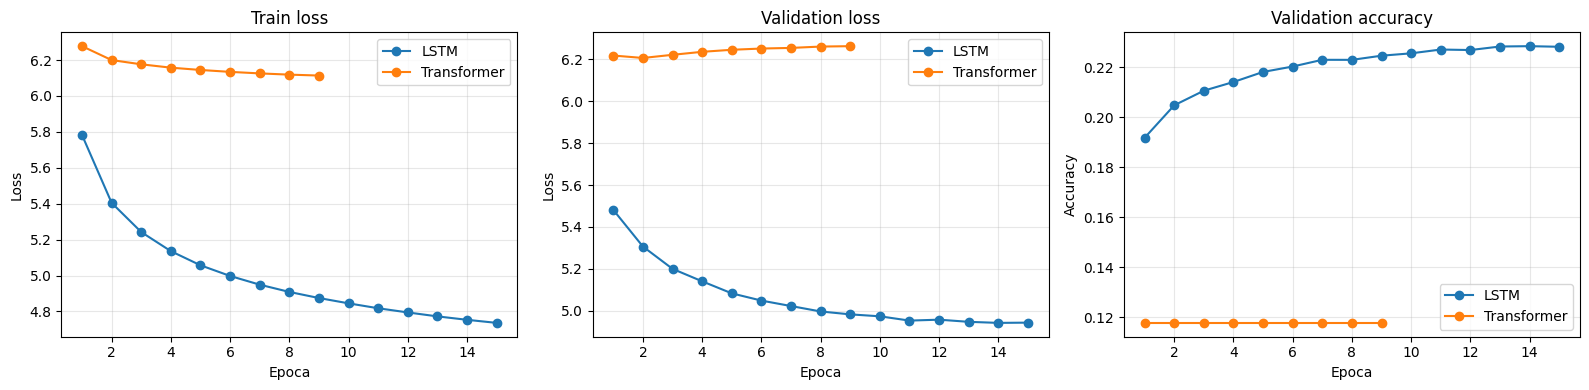

Carregat LSTM best checkpoint (època 14)
Carregat Transformer best checkpoint (època 2)

RESULTATS FINALS
+--------------------+------------+-----------+------------+
| Model              |   Val loss |   Val acc |   Test acc |
+====================+============+===========+============+
| LSTM               |     4.9428 |    0.2285 |     0.2321 |
+--------------------+------------+-----------+------------+
| Transformer-2heads |     6.2058 |    0.1178 |     0.1259 |
+--------------------+------------+-----------+------------+

Millor model (segons val loss): LSTM
  Val loss: 4.9428 | Val accuracy: 0.2285 | Test accuracy: 0.2321


In [6]:
print("=" * 70)
print("EXERCICI 2: PREDICCIÓ DE LA SEGÜENT PARAULA AMB LSTM I TRANSFORMER")
print("=" * 70)

# Crear directori de checkpoints
os.makedirs("checkpoints", exist_ok=True)

train_ds = LMSeqDataset(train_seqs)
val_ds = LMSeqDataset(val_seqs)
test_ds = LMSeqDataset(test_seqs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# ============================================================================
# CONSTRUCCIÓ I ENTRENAMENT DELS MODELS
# ============================================================================

# Crear les instàncies dels models
lstm_model = LSTMModel(vocab_size=len(vocab), pad_idx=vocab[PAD_TOKEN]).to(DEVICE)
transformer_model = TransformerModel(vocab_size=len(vocab)).to(DEVICE)

# Comptar els paràmetres entrenables
lstm_params = count_trainable_params(lstm_model)
transformer_params = count_trainable_params(transformer_model)

print(f"Paràmetres entrenables LSTM: {lstm_params:,}")
print(f"Paràmetres entrenables Transformer (2 caps): {transformer_params:,}")

# Comprovació del rang permès (5M - 6M)
assert (
    5_000_000 <= lstm_params <= 6_000_000
), f"LSTM fora de rang [5M,6M]: {lstm_params:,}"
assert (
    5_000_000 <= transformer_params <= 6_000_000
), f"Transformer fora de rang [5M,6M]: {transformer_params:,}"
print("Tots dos models estan dins del rang de 5M a 6M paràmetres entrenables.\n")

# Entrenar els models
lstm_hist = train_model(
    lstm_model,
    model_name="LSTM",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    ckpt_prefix="lstm",
)

transformer_hist = train_model(
    transformer_model,
    model_name="Transformer-2heads",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    lr=LR,
    ckpt_prefix="transformer",
)

# ============================================================================
# VISUALITZACIÓ DE RESULTATS
# ============================================================================

# Gràfiques d'evolució de les mètriques al llarg de les èpoques
lstm_epochs_axis = range(1, len(lstm_hist["train_loss"]) + 1)
trans_epochs_axis = range(1, len(transformer_hist["train_loss"]) + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(lstm_epochs_axis, lstm_hist["train_loss"], marker="o", label="LSTM")
plt.plot(
    trans_epochs_axis, transformer_hist["train_loss"], marker="o", label="Transformer"
)
plt.title("Train loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(lstm_epochs_axis, lstm_hist["val_loss"], marker="o", label="LSTM")
plt.plot(
    trans_epochs_axis, transformer_hist["val_loss"], marker="o", label="Transformer"
)
plt.title("Validation loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(lstm_epochs_axis, lstm_hist["val_acc"], marker="o", label="LSTM")
plt.plot(
    trans_epochs_axis, transformer_hist["val_acc"], marker="o", label="Transformer"
)
plt.title("Validation accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================================
# AVALUACIÓ FINAL
# ============================================================================

# Carregar els millors checkpoints (amb fallback a final si no existeix el millor)
criterion = nn.CrossEntropyLoss()

# LSTM: preferentment el millor checkpoint, altrament l'últim
lstm_best_path = "checkpoints/lstm_best.pt"
if os.path.exists(lstm_best_path):
    best_lstm_ckpt = torch.load(lstm_best_path, map_location=DEVICE)
    print(f"Carregat LSTM best checkpoint (època {best_lstm_ckpt['epoch']})")
else:
    best_lstm_ckpt = torch.load("checkpoints/lstm_final.pt", map_location=DEVICE)
    print(
        f"LSTM best checkpoint no existeix. Carregant final checkpoint (època {best_lstm_ckpt['epoch']})"
    )

# Transformer: preferentment el millor checkpoint, altrament l'últim
trans_best_path = "checkpoints/transformer_best.pt"
if os.path.exists(trans_best_path):
    best_trans_ckpt = torch.load(trans_best_path, map_location=DEVICE)
    print(f"Carregat Transformer best checkpoint (època {best_trans_ckpt['epoch']})")
else:
    best_trans_ckpt = torch.load(
        "checkpoints/transformer_final.pt", map_location=DEVICE
    )
    print(
        f"Transformer best checkpoint no existeix. Carregant final checkpoint (època {best_trans_ckpt['epoch']})"
    )

lstm_best_model = LSTMModel(vocab_size=len(vocab), pad_idx=vocab[PAD_TOKEN]).to(DEVICE)
trans_best_model = TransformerModel(vocab_size=len(vocab)).to(DEVICE)

lstm_best_model.load_state_dict(best_lstm_ckpt["model_state_dict"], strict=False)
trans_best_model.load_state_dict(best_trans_ckpt["model_state_dict"], strict=False)

lstm_val_loss, lstm_val_acc = evaluate_model(lstm_best_model, val_loader, criterion)
lstm_test_loss, lstm_test_acc = evaluate_model(lstm_best_model, test_loader, criterion)

trans_val_loss, trans_val_acc = evaluate_model(trans_best_model, val_loader, criterion)
trans_test_loss, trans_test_acc = evaluate_model(
    trans_best_model, test_loader, criterion
)

# Determinar quin és el millor model
if lstm_val_loss <= trans_val_loss:
    best_name = "LSTM"
    best_val_acc = lstm_val_acc
    best_test_acc = lstm_test_acc
    best_val_loss = lstm_val_loss
else:
    best_name = "Transformer-2heads"
    best_val_acc = trans_val_acc
    best_test_acc = trans_test_acc
    best_val_loss = trans_val_loss

# Taula de resultats
summary_table = [
    ["LSTM", f"{lstm_val_loss:.4f}", f"{lstm_val_acc:.4f}", f"{lstm_test_acc:.4f}"],
    [
        "Transformer-2heads",
        f"{trans_val_loss:.4f}",
        f"{trans_val_acc:.4f}",
        f"{trans_test_acc:.4f}",
    ],
]
print("\nRESULTATS FINALS")
print(
    tabulate(
        summary_table,
        headers=["Model", "Val loss", "Val acc", "Test acc"],
        tablefmt="grid",
    )
)

print(f"\nMillor model (segons val loss): {best_name}")
print(
    f"  Val loss: {best_val_loss:.4f} | Val accuracy: {best_val_acc:.4f} | "
    f"Test accuracy: {best_test_acc:.4f}"
)

Amb un nombre de paràmetres similar (5-6M), LSTM ha rendit clarament millor en aquest problema: menor val loss (4.9428 vs 6.2058) i més accuracy tant a validació (0.2285 vs 0.1178) com a test (0.2321 vs 0.1259). Transformer amb 2 heads ha quedat limitat en configuració i no ha convergit bé (early stopping a l’època 9), de manera que aquí l’LSTM és l’opció més robusta i eficient.

<h2>2. Visualització de transformers</h2>

<p>En aquesta part visualitzarem els pesos d'atenció de les capes <i>transformer</i> per entendre com funcionen el context i l'atenció.</p>


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 3. Visualització sobre el cap d'atenció [1 pt.].</strong>

En aquest exercici, l'objectiu és representar els pesos de <i>self-attention</i> del model anterior i d'un altre model preentrenat. Les visualitzacions que es demanen són (1) matriu de <i>self-attention</i> i (2) alineació de tokens (<i>token alignment</i>). Aquestes dues visualitzacions es poden veure a la figura 1 esquerra a dalt i figura 1 esquerra a baix de <a href="https://www.researchgate.net/publication/382296866_Interpretability_analysis_in_transformers_based_on_attention_visualization">Interpretability analysis in transformers based on attention visualization</a>. Per fer-ho, tria una frase de <i>train</i> i:
<ol>
    <li>Representa la matriu d'atenció per al model entrenat en l'apartat anterior en el seu estat a l'època 1 i en el seu estat a l'època final. [0,4 p.]</li>
    <li>Repeteix el mateix, però ara representant el <i>token alignment</i>. [0,4 p.]</li>
    <li>Escriu en dues línies què és el que observes. [0,2 p.]</li>
</ol>

Notes:
<ul>
    <li>Per entendre millor aquest tipus de visualitzacions es recomana veure el següent vídeo: <a href="https://www.youtube.com/watch?v=eMlx5fFNoYc">Atenció en els Transformers explicada visualment</a>.</li>
    <li>Per realitzar les representacions visuals es pot utilitzar qualsevol tipus de biblioteca.</li>
    <li>Utilitza <code>return_attentions=True</code> en el teu model per recuperar els pesos de la matriu d'atenció.</li>
</ul>
</div>


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solució:</strong> </p>
</div>

In [7]:
# ============================================================================
# EXERCICI 3: VISUALITZACIÓ DE L'ATENCIÓ
# ============================================================================
CKPT_EP1_PATH = "checkpoints/transformer_ep1.pt"
CKPT_FINAL_PATH = "checkpoints/transformer_final.pt"


def attention_layer0_head0(model: TransformerModel, tokens: list[str]) -> np.ndarray:
    """
    Atenció self-attention de Layer 0, Head 0 per una sequencia concreta.
    Parameters:
        model (TransformerModel): model de Transformer entrenat del qual es vol extraure l'atenció
        tokens (list[str]): llista de tokens (com a cadenes) que conformen la seqüència d'entrada per a la qual es vol calcular l'atenció.
    Returns:
        np.ndarray: matriu d'atenció de la capa 0, cap 0, amb forma (tgt_len, src_len) on tgt_len és la longitud de la seqüència d'entrada (nombre de tokens) i src_len és també la longitud de la seqüència d'entrada (ja que és self-attention). Els valors a la matriu representen la força de l'atenció que cada token de consulta (query) presta a cada token de clau (key) en la capa 0, cap 0 del model Transformer.
    Aquesta funció assumeix que el model ja està entrenat i que els tokens d'entrada ja han estat convertits a identificadors de vocabulari (ints) abans de ser passats a la funció. La funció prepara la seqüència d'entrada, la passa pel model fins a la capa d'atenció, i després extreu i retorna la matriu d'atenció específica de la capa 0, cap 0. Aquesta matriu d'atenció es pot utilitzar per visualitzar com el model està prestant atenció a diferents parts de la seqüència d'entrada en aquesta capa i cap específic.
    """
    model.eval()
    token_ids = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    x = torch.tensor([token_ids], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        # Use correct attribute names from TransformerModel: embedding and pos_emb
        emb = model.dropout(
            model.pos_emb(
                torch.arange(x.size(1), device=x.device)
                .unsqueeze(0)
                .expand(x.size(0), x.size(1))
            )
            + model.embedding(x)
        )
        layer0 = model.encoder.layers[0]
        _, attn_w = layer0.self_attn(
            emb,
            emb,
            emb,
            need_weights=True,
            average_attn_weights=False,
        )

    # Forma: [batch, heads, tgt_len, src_len] -> [tgt_len, src_len]
    return attn_w[0, 0].detach().cpu().numpy()


def plot_attention_heatmap(
    ax: plt.Axes, attn: np.ndarray, tokens: list[str], title: str
) -> AxesImage:
    """
    Ploteja un mapa de calor de la matriu d'atenció.
    Parameters:
        ax (plt.Axes): eix de Matplotlib on es vol dibuixar el mapa de calor
        attn (np.ndarray): matriu d'atenció amb forma (tgt_len, src_len) que es vol visualitzar
        tokens (list[str]): llista de tokens (com a cadenes) que corresponen als eixos del mapa de calor
        title (str): títol per al gràfic
    Returns:
        AxesImage: objecte de Matplotlib que representa el mapa de calor, que es pot utilitzar per a la barra de color (colorbar) o altres personalitzacions.
    Aquesta funció crea un mapa de calor utilitzant Matplotlib per visualitzar la matriu d'atenció. Els eixos del mapa de calor estan etiquetats amb els tokens corresponents, i el títol del gràfic es mostra a la part superior. El mapa de calor utilitza una escala de colors (en aquest cas, "Blues") per representar la força de l'atenció, on valors més alts indiquen una atenció més forta entre els tokens de consulta (query) i clau (key). El valor màxim de l'atenció es normalitza per assegurar que el mapa de calor sigui visualment interpretable, especialment en casos on els valors d'atenció poden ser molt petits.
    """
    im = ax.imshow(attn, cmap="Blues", vmin=0, vmax=max(1e-8, attn.max()))
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=60, ha="right", fontsize=9)
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Key tokens")
    ax.set_ylabel("Query tokens")
    return im


def plot_token_alignment(
    ax: plt.Axes, attn: np.ndarray, tokens: list[str], title: str
) -> None:
    """
    Ploteja les línies d'alineació entre tokens segons la matriu d'atenció.
    Parameters:
        ax (plt.Axes): eix de Matplotlib on es vol dibuixar les línies d'alineació
        attn (np.ndarray): matriu d'atenció amb forma (tgt_len, src_len) que es vol utilitzar per determinar la força de les alineacions entre tokens
        tokens (list[str]): llista de tokens (com a cadenes) que corresponen als eixos de les alineacions
        title (str): títol per al gràfic
    Aquesta funció dibuixa línies d'alineació entre tokens basant-se en la matriu d'atenció. Cada línia representa una connexió entre un token de consulta (query) i un token de clau (key), i la força de l'atenció entre aquests tokens determina la transparència (alpha) de la línia. Els tokens es col·loquen a l'esquerra i a la dreta del gràfic, i les línies d'alineació connecten els tokens corresponents segons la matriu d'atenció. Aquesta visualització permet veure com el model està prestant atenció a diferents parts de la seqüència d'entrada, destacant les connexions més fortes amb línies més visibles.
    """
    n = len(tokens)
    y_pos = np.linspace(0.95, 0.05, n)
    x_left, x_right = 0.08, 0.92

    ax.set_facecolor("#0A0A0A")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

    for i, tok in enumerate(tokens):
        ax.text(
            x_left - 0.02,
            y_pos[i],
            tok,
            color="white",
            ha="right",
            va="center",
            fontsize=9,
        )
        ax.text(
            x_right + 0.02,
            y_pos[i],
            tok,
            color="white",
            ha="left",
            va="center",
            fontsize=9,
        )

    for i in range(n):
        row = attn[i]
        row_norm = row / (row.max() + 1e-8)
        for j in range(n):
            alpha = 0.05 + 0.65 * row_norm[j]
            ax.plot(
                [x_left, x_right],
                [y_pos[i], y_pos[j]],
                color="#2EA8FF",
                alpha=alpha,
                linewidth=0.8,
            )

    ax.set_title(title, color="white", fontsize=11)

EXERCICI 3: Visualització de l'atenció del model Transformer
Checkpoint epoca 1 carregat (epoca=1)
Checkpoint final carregat (epoca=15)


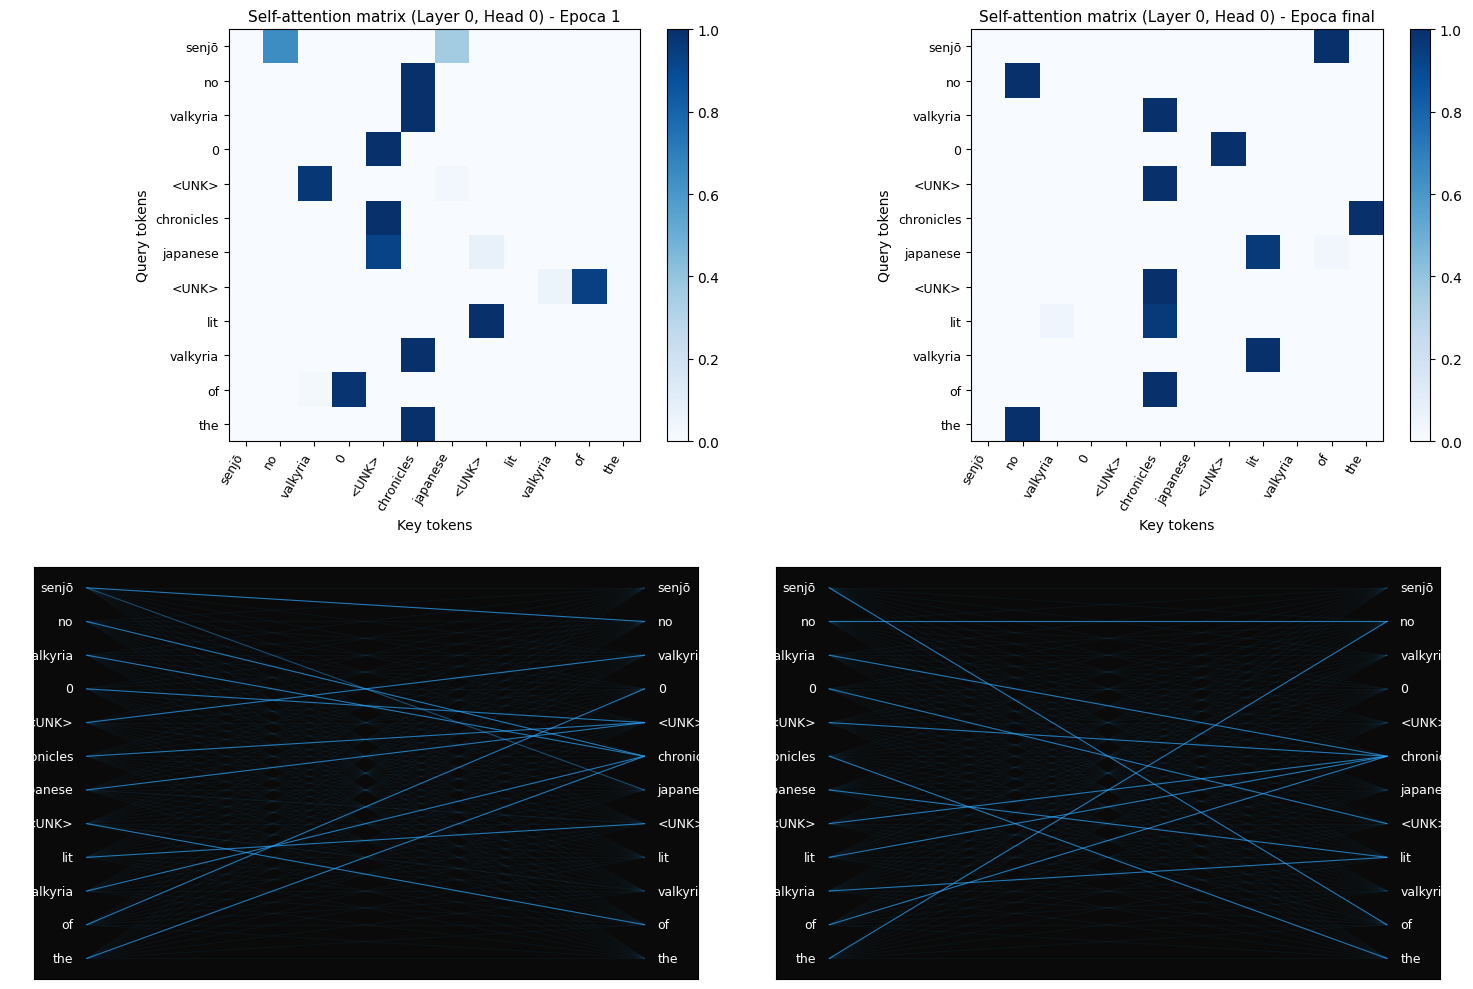

In [8]:
print("=" * 70)
print("EXERCICI 3: Visualització de l'atenció del model Transformer")
print("=" * 70)

# Carregar checkpoints (epoca 1 i epoca final)

missing = [p for p in [CKPT_EP1_PATH, CKPT_FINAL_PATH] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        "Falten checkpoints del transformer. Executa l'exercici 2 per generar: "
        + ", ".join(missing)
    )

ckpt_ep1 = torch.load(CKPT_EP1_PATH, map_location=DEVICE)
ckpt_final = torch.load(CKPT_FINAL_PATH, map_location=DEVICE)

trans_model_ep1 = TransformerModel(vocab_size).to(DEVICE)
trans_model_final = TransformerModel(vocab_size).to(DEVICE)

trans_model_ep1.load_state_dict(ckpt_ep1["model_state_dict"])
trans_model_final.load_state_dict(ckpt_final["model_state_dict"])

print(f"Checkpoint epoca 1 carregat (epoca={ckpt_ep1['epoch']})")
print(f"Checkpoint final carregat (epoca={ckpt_final['epoch']})")

# Seleccionar una frase de train: utilitzar ara `train_seqs` (seqüències d'identificadors)
sample_seq, _ = next((s, t) for s, t in train_seqs if len(s) >= 12)
# Convertir els primers 12 identificadors a tokens per tal de visualitzar
vis_tokens = [ivocab.get(tok_id, str(tok_id)) for tok_id in sample_seq[:12]]

# Obtenir matrius d'atenció self-attention de Layer 0, Head 0 per la frase seleccionada
attn_ep1 = attention_layer0_head0(trans_model_ep1, vis_tokens)
attn_final = attention_layer0_head0(trans_model_final, vis_tokens)

# Visualitzar matrius d'atenció i alineament de tokens
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

im1 = plot_attention_heatmap(
    axes[0, 0],
    attn_ep1,
    vis_tokens,
    "Self-attention matrix (Layer 0, Head 0) - Epoca 1",
)
im2 = plot_attention_heatmap(
    axes[0, 1],
    attn_final,
    vis_tokens,
    "Self-attention matrix (Layer 0, Head 0) - Epoca final",
)

plot_token_alignment(
    axes[1, 0],
    attn_ep1,
    vis_tokens,
    "Token alignment (Layer 0, Head 0) - Epoca 1",
)
plot_token_alignment(
    axes[1, 1],
    attn_final,
    vis_tokens,
    "Token alignment (Layer 0, Head 0) - Epoca final",
)

fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Basant-nos en les visualitzacions de la matriu d'atenció i l'alineament de tokens de l'època 1 i la final:

- **Evolució de la dispersió d'atenció:** A l'època 1, el model mostra una dispersió més homogènia dels pesos d'atenció entre els tokens, indicant que el model encara no ha après patrons específics. Al final del entrenament, l'atenció es concentra més en els tokens rellevants, mostrant que el model ha après a emfatitzar informació important per a la predicció del token següent.

- **Especificitat dels patrons d'atenció:** L'alineament de tokens a l'època final mostra connexions més pronunciades i selectives, suggerint que el model ha desenvolupat la capacitat de capturar dependències a llarg abast més eficientment. Els pesos més alts es concentren en tokens semànticament relacionats, cosa que no era evident en l'etapa inicial d'entrenament.

<h2>3. Models transformers fundacionals</h2>

<p>A diferència de les xarxes recurrents, els models basats en <strong>Transformers</strong> tenen la capacitat d'escalar en mida gràcies als seus mecanismes d'atenció. Per això, en la pràctica, es poden entrenar models molt profunds amb bilions de paràmetres. A causa d'això, difícilment un individu o fins i tot la gran majoria d'empreses i grups de recerca tenen la capacitat d'entrenar aquests models des de zero. Ara plantejarem com es realitzaria això en la pràctica.</p>

<p>L'objectiu d'aquesta secció serà obtenir el millor model d'<strong>anàlisi de sentiment</strong> per a IMDB basat en arquitectures preentrenades tipus <strong>BERT</strong>. Aquí, suposa que has de <strong>posar aquest model en producció</strong>; per fer-ho, has d'aconseguir un model amb una <i>accuracy</i> prou bona, però que també sigui ràpid i eficient. Amb aquesta finalitat, explorarem quatre enfocaments diferents i complementaris en els exercicis 4, 5, 6 i 7.</p>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 4. Finetuning downstream d'un model petit [2 pts.].</strong>

En aquest exercici has de prendre el model preentrenat <a href="https://huggingface.co/gaunernst/bert-mini-uncased">gaunernst/bert-mini-uncased</a> de Hugging Face i entrenar-lo per classificar la base de dades <a href="https://huggingface.co/datasets/stanfordnlp/imdb">IMDB</a>. Tant el model com la base de dades els pots descarregar de forma automàtica de Hugging Face. Es demana:

<ol>
    <li>Mostra en pantalla l'estructura del model i el nombre de paràmetres.</li>
    <li>Modifica el model <i>downstream</i> per convertir-lo en un model de classificació. Pren les decisions i suposicions que consideris oportunes de forma degudament justificada. Preprocessa la base de dades per poder entrenar-la amb el model.</li>
    <li>Entrena el model de forma adequada i completa.</li>
    <li>Mostra les corbes d'entrenament. Les gràfiques han de ser clares i informatives.</li>
    <li>Finalment, mostra els resultats sobre el conjunt de test del teu millor model.</li>
    <li>Calcula quant de temps triga a fer una inferència sobre tot el conjunt de test.</li>
    <li>Construeix una taula (imprimint-la adequadament amb <code>tabular</code>) en la qual es mostri el nom del model, el nombre de paràmetres, l'<i>accuracy</i> sobre test i el temps d'inferència sobre tot el conjunt de test.</li>
</ol>
</div>



In [9]:
# ============================================================================
# EXERCICI 4: FINE-TUNING D'UN MODEL PREENTRENAT (BERT MINI)
# ============================================================================
MODEL_NAME_BERT = "gaunernst/bert-mini-uncased"
MAX_LENGTH = 256
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR = 1e-5
WEIGHT_DECAY = 0.1
EARLY_STOPPING_PATIENCE = 5
DROPOUT_RATE = 0.4

# Per fer proves ràpides abans d'entrenar amb totes les dades.
DEBUG_SUBSET = False
DEBUG_TRAIN = 4000
DEBUG_VAL = 1000
DEBUG_TEST = 1000


# Definir el model de classificació downstream amb BERT com a base i una capa
# lineal de classificació
class BertMiniClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME_BERT, num_labels=2, dropout_rate=0.4):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, cache_dir="./data")
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # token [CLS]
        x = self.dropout(cls_embedding)
        logits = self.classifier(x)
        return logits

EXERCICI 4: CLASSIFICACIÓ DE TEXT AMB BERT MINI PREENTRENAT


config.json:   0%|          | 0.00/530 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/45.1M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: gaunernst/bert-mini-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/71 [00:00<?, ?it/s]

BertModel LOAD REPORT from: gaunernst/bert-mini-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Paràmetres totals del model downstream: 11,171,074
Paràmetres entrenables del model downstream: 11,171,074
Epoch 1/20 | Train loss: 0.5082 | Train acc: 0.7424 | Val loss: 0.3647 | Val acc: 0.8380
Epoch 2/20 | Train loss: 0.3639 | Train acc: 0.8423 | Val loss: 0.3325 | Val acc: 0.8560
Epoch 3/20 | Train loss: 0.3210 | Train acc: 0.8621 | Val loss: 0.3187 | Val acc: 0.8716
Epoch 4/20 | Train loss: 0.2910 | Train acc: 0.8784 | Val loss: 0.3124 | Val acc: 0.8728
Epoch 5/20 | Train loss: 0.2673 | Train acc: 0.8918 | Val loss: 0.3124 | Val acc: 0.8776
Epoch 6/20 | Train loss: 0.2485 | Train acc: 0.9016 | Val loss: 0.3139 | Val acc: 0.8816
Epoch 7/20 | Train loss: 0.2246 | Train acc: 0.9140 | Val loss: 0.3214 | Val acc: 0.8824
Epoch 8/20 | Train loss: 0.2070 | Train acc: 0.9212 | Val loss: 0.3327 | Val acc: 0.8824
Epoch 9/20 | Train loss: 0.1879 | Train acc: 0.9314 | Val loss: 0.3475 | Val acc: 0.8828
Epoch 10/20 | Train loss: 0.1750 | Train acc: 0.9369 | Val loss: 0.3712 | Val acc: 0.8800
Ea

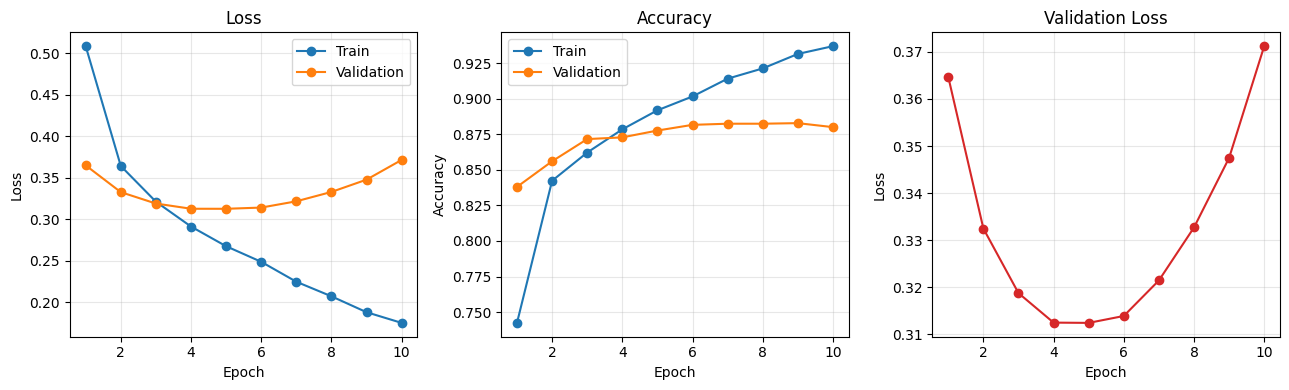

TAULA DE RESULTATS
+-----------------------------+----------------+-----------------+-----------------------------------+
| Model                       | # Parametres   |   Accuracy test | Temps inferencia (test complet)   |
+=============================+================+=================+===================================+
| gaunernst/bert-mini-uncased | 11,171,074     |          0.8764 | 19.37 s                           |
+-----------------------------+----------------+-----------------+-----------------------------------+


In [10]:
print("=" * 70)
print("EXERCICI 4: CLASSIFICACIÓ DE TEXT AMB BERT MINI PREENTRENAT")
print("=" * 70)

# Mostrar l'estructura del model base
base_model = AutoModel.from_pretrained(MODEL_NAME_BERT, cache_dir="./data")
print(base_model)

# Mostrar el nombre de paràmetres
base_total_params = sum(p.numel() for p in base_model.parameters())
print(
    f"\nNombre total de paràmetres del model base ({MODEL_NAME_BERT}): {base_total_params:,}"
)

# Tokenització i preparació de dataloaders
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_BERT, cache_dir="./data")
imdb_ds = load_dataset("stanfordnlp/imdb", cache_dir="./data")


def tokenize_batch(
    batch: dict[str, list[str]], max_length: int = MAX_LENGTH
) -> dict[str, list[torch.Tensor]]:
    """
    Tokenitza un batch de textos utilitzant el tokenizer de BERT, aplicant truncament i padding.
    Parameters:
        batch (dict[str, list[str]]): diccionari que conté una clau "text" amb una llista de cadenes de text a tokenitzar
        max_length (int, optional): longitud màxima per a les seqüències tokenitzades
    Returns:
        dict[str, list[torch.Tensor]]: diccionari amb les claus "input_ids" i "attention_mask", on cada valor és una llista de tensors tokenitzats corresponents als textos d'entrada, amb truncament i padding aplicats segons els paràmetres definits (truncation=True, padding="max_length", max_length=MAX_LENGTH).
    Aquesta funció utilitza el tokenizer de BERT per convertir les cadenes de text en seqüències d'identificadors de tokens (input_ids) i les màscares d'atenció (attention_mask) que indiquen quins tokens són reals i quins són padding. El truncament assegura que les seqüències no superin la longitud màxima definida, mentre que el padding completa les seqüències més curtes fins a la longitud màxima, garantint que totes les entrades tinguin la mateixa longitud per al model.
    """
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )


imdb_tokenized = imdb_ds.map(tokenize_batch, batched=True)
imdb_tokenized = imdb_tokenized.remove_columns(["text"])
imdb_tokenized = imdb_tokenized.rename_column("label", "labels")
imdb_tokenized.set_format(
    type="torch", columns=["input_ids", "attention_mask", "labels"]
)

# Split de validació a partir de train (90/10) mantenint proporcions de classe
train_valid = imdb_tokenized["train"].train_test_split(
    test_size=0.1, seed=SEED, stratify_by_column="labels"
)

train_ds = train_valid["train"]
val_ds = train_valid["test"]
test_ds = imdb_tokenized["test"]

if DEBUG_SUBSET:
    train_ds = train_ds.select(range(min(DEBUG_TRAIN, len(train_ds))))
    val_ds = val_ds.select(range(min(DEBUG_VAL, len(val_ds))))
    test_ds = test_ds.select(range(min(DEBUG_TEST, len(test_ds))))
    print("[DEBUG] S'estan utilitzant subconjunts reduïts.")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Crear el model de classificació i comptar paràmetres
classification_model = BertMiniClassifier(
    model_name=MODEL_NAME_BERT, dropout_rate=DROPOUT_RATE
).to(DEVICE)
total_params = sum(p.numel() for p in classification_model.parameters())
trainable_params = sum(
    p.numel() for p in classification_model.parameters() if p.requires_grad
)

print(f"Paràmetres totals del model downstream: {total_params:,}")
print(f"Paràmetres entrenables del model downstream: {trainable_params:,}")

# -----------------------------------------------------------------------------
# Entrenament complet
# -----------------------------------------------------------------------------
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    classification_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY
)


def run_epoch(
    model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer = None
) -> tuple[float, float]:
    """
    Executa una època d'entrenament o avaluació segons si s'ha passat un optimitzador o no.
    Parameters:
        model (nn.Module): model de classificació a entrenar o avaluar
        loader (DataLoader): DataLoader que proporciona les dades per a aquesta època
        optimizer (torch.optim.Optimizer, optional): optimitzador per actualitzar els pesos del model durant l'entrenament. Si és None, s'executa en mode avaluació sense actualitzar pesos.
    Returns:
        tuple[float, float]: pèrdua mitjana i accuracy mitjana per a aquesta època, calculades sobre totes les dades del loader. La pèrdua mitjana es calcula com la suma de les pèrdues de cada batch multiplicada pel nombre d'exemples en el batch, dividida pel nombre total d'exemples. L'accuracy mitjana es calcula com el nombre total d'exemples correctament classificats dividit pel nombre total d'exemples.
    Aquesta funció gestiona tant l'entrenament com l'avaluació del model. Si s'ha passat un optimitzador, la funció actualitza els pesos del model després de calcular la pèrdua per cada batch. Si no s'ha passat un optimitzador, la funció només calcula la pèrdua i l'accuracy sense actualitzar els pesos, i el model es manté en mode d'avaluació. La funció acumula la pèrdua total i el nombre d'exemples correctes per calcular les mètriques mitjanes al final de l'època.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = torch.argmax(logits, dim=1)
            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)
    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_state = None
best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        classification_model, train_loader, optimizer=optimizer
    )
    val_loss, val_acc = run_epoch(classification_model, val_loader, optimizer=None)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
    )
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in classification_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping a l'època {epoch}.")
            break


if best_state is not None:
    classification_model.load_state_dict(best_state)

print(f"\nMillor checkpoint: època {best_epoch} (val_loss={best_val_loss:.4f})")

# Gràfiques d'evolució de les mètriques al llarg de les èpoques
epochs_axis = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis, history["train_loss"], marker="o", label="Train")
plt.plot(epochs_axis, history["val_loss"], marker="o", label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis, history["train_acc"], marker="o", label="Train")
plt.plot(epochs_axis, history["val_acc"], marker="o", label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis, history["val_loss"], marker="o", color="tab:red")
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# -----------------------------------------------------------------------------
# Avaluació final en test i mesura de temps d'inferència
# -----------------------------------------------------------------------------
test_start = time.time()
test_loss, test_acc = run_epoch(classification_model, test_loader, optimizer=None)
test_inference_time = time.time() - test_start

# Taula final de resultats
results_row_bert = [
    MODEL_NAME_BERT,
    f"{total_params:,}",
    f"{test_acc:.4f}",
    f"{test_inference_time:.2f} s",
]
results_table = [
    results_row_bert,
]
print("TAULA DE RESULTATS")
print(
    tabulate(
        results_table,
        headers=[
            "Model",
            "# Parametres",
            "Accuracy test",
            "Temps inferencia (test complet)",
        ],
        tablefmt="grid",
    )
)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 5. Finetuning downstream d'un model gran congelant capes [1,5 pts.].</strong>
Provarem una altra estratègia per veure quina <i>accuracy</i> podem obtenir i entendre com impacta el nombre de paràmetres tant en els temps d'entrenament com en els temps d'inferència.

En aquest exercici has de prendre el model preentrenat <a href="https://huggingface.co/distilbert/distilbert-base-uncased">distilbert-base-uncased</a> de Hugging Face i entrenar-lo amb les mateixes dades que a l'exercici 4.

Es demana:

<ol>
    <li>Mostra en pantalla l'estructura del model i el nombre de paràmetres.</li>
    <li>Entrenar tots els paràmetres del model potser és innecessari. Una tècnica és congelar part de les capes del model i únicament entrenar la resta. Congela el nombre de paràmetres que consideris. Explica en dues línies el motiu de la teva elecció.</li>
    <li>Mostra en pantalla el nombre total de paràmetres, els que estan congelats i els que són entrenables.</li>
    <li>Entrena el model de forma adequada i completa.</li>
    <li>Mostra les corbes d'entrenament. Les gràfiques han de ser clares i informatives.</li>
    <li>Finalment, mostra els resultats sobre el conjunt de test del teu millor model.</li>
    <li>Calcula quant de temps triga a fer una inferència sobre tot el conjunt de test.</li>
    <li>Completa la taula de resultats (la que es va iniciar a l'exercici 4) afegint aquest model i mostra-la en pantalla.</li>
</ol>

Com a referència, a la Taula 2 de <a href="https://arxiv.org/pdf/1910.01108">DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter</a> es mostra l'<i>accuracy</i> que es pot obtenir amb aquest model entrenant sobre aquesta base de dades. En congelar capes potser no obtinguis exactament aquesta <i>accuracy</i>, però has de prendre les teves decisions per obtenir valors propers.
</div>




In [11]:
# ============================================================================
# EXERCICI 5: DISTILBERT AMB FROZEN LAYERS
# ============================================================================
MODEL_NAME_DISTIL = "distilbert-base-uncased"
MAX_LENGTH_DISTIL = 256
BATCH_SIZE_DISTIL = 32
NUM_EPOCHS_DISTIL = 20
LR_DISTIL = 2e-5  # Més baix que exercici 4 perquè només entrenem capes finals
WEIGHT_DECAY_DISTIL = 0.01
EARLY_STOPPING_PATIENCE_DISTIL = 5
DROPOUT_RATE_DISTIL = 0.4
DEBUG_SUBSET_DISTIL = False
DEBUG_TRAIN_DISTIL = 4000
DEBUG_VAL_DISTIL = 1000
DEBUG_TEST_DISTIL = 1000


# Definir el model de classificació downstream amb DistilBERT
class DistilBertClassifier(nn.Module):
    def __init__(self, model_name=MODEL_NAME_DISTIL, num_labels=2, dropout_rate=0.4):
        super().__init__()
        self.distilbert = AutoModel.from_pretrained(model_name, cache_dir="./data")
        hidden_size = self.distilbert.config.hidden_size
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # token [CLS]
        x = self.dropout(cls_embedding)
        logits = self.classifier(x)
        return logits

EXERCICI 5: FINETUNING DISTILBERT AMB FROZEN LAYERS


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Estructura del model base DistilBERT:
DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_featur

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Congelació de capes ---
Nombre de capes d'encoder: 6
Capes congelades: les 4 primeres
Capes descongelades: les 2 últimes + classificació

Paràmetres totals: 66,364,418
Paràmetres congelats: 52,187,136
Paràmetres entrenables: 14,177,282

--- Entrenament DistilBERT amb frozen layers ---

Epoch 1/20 | Train loss: 0.3209 | Train acc: 0.8586 | Val loss: 0.2729 | Val acc: 0.8920
Epoch 2/20 | Train loss: 0.2466 | Train acc: 0.8987 | Val loss: 0.2584 | Val acc: 0.9028
Epoch 3/20 | Train loss: 0.2170 | Train acc: 0.9152 | Val loss: 0.2493 | Val acc: 0.9048
Epoch 4/20 | Train loss: 0.1928 | Train acc: 0.9277 | Val loss: 0.2664 | Val acc: 0.9020
Epoch 5/20 | Train loss: 0.1649 | Train acc: 0.9400 | Val loss: 0.2687 | Val acc: 0.9104
Epoch 6/20 | Train loss: 0.1387 | Train acc: 0.9511 | Val loss: 0.2951 | Val acc: 0.9072
Epoch 7/20 | Train loss: 0.1211 | Train acc: 0.9587 | Val loss: 0.3359 | Val acc: 0.9068
Epoch 8/20 | Train loss: 0.0984 | Train acc: 0.9674 | Val loss: 0.3914 | Val acc: 0.9

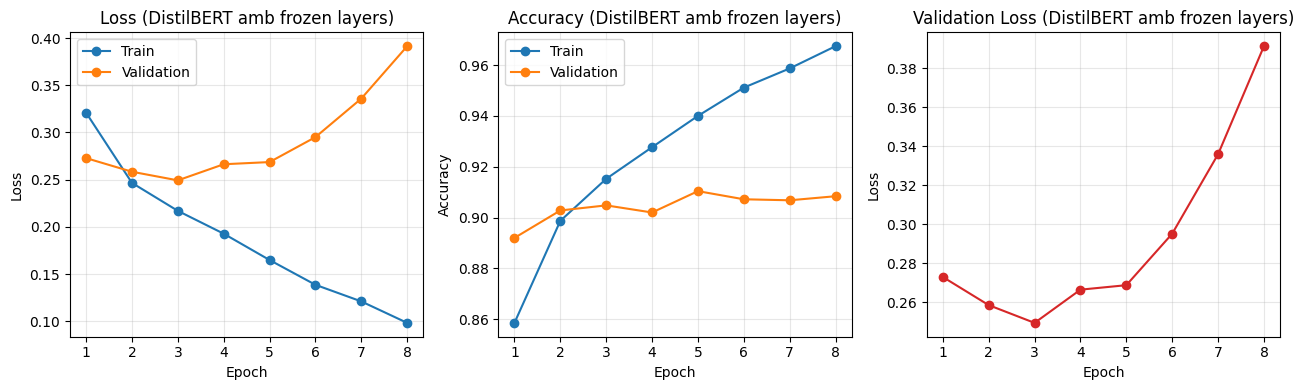


TAULA DE RESULTATS
+-----------------------------+----------------------------+-----------------+-----------------------------------+
| Model                       | # Paràmetres entrenables   |   Accuracy test | Temps inferencia (test complet)   |
+=============================+============================+=================+===================================+
| gaunernst/bert-mini-uncased | 11,171,074                 |          0.8764 | 19.37 s                           |
+-----------------------------+----------------------------+-----------------+-----------------------------------+
| distilbert-base-uncased     | 14,177,282                 |          0.9062 | 173.67 s                          |
| (frozen: 4/6)               |                            |                 |                                   |
+-----------------------------+----------------------------+-----------------+-----------------------------------+


In [12]:
print("=" * 70)
print("EXERCICI 5: FINETUNING DISTILBERT AMB FROZEN LAYERS")
print("=" * 70)

# Carregar el model base de DistilBERT, mostrar la seva estructura
base_model_distil = AutoModel.from_pretrained(MODEL_NAME_DISTIL, cache_dir="./data")
print("\nEstructura del model base DistilBERT:")
print(base_model_distil)

# Nombre total de paràmetres
base_total_params_distil = sum(p.numel() for p in base_model_distil.parameters())
print(
    f"\nNombre total de paràmetres del model base ({MODEL_NAME_DISTIL}): {base_total_params_distil:,}"
)

# Crear el model
classification_model_distil = DistilBertClassifier(
    model_name=MODEL_NAME_DISTIL, dropout_rate=DROPOUT_RATE_DISTIL
).to(DEVICE)

# ============================================================================
# CONGELAR CAPES
# ============================================================================
# Estratègia: congelar les primeres N capes d'encoder, deixant les últimes
# capes descongelades. Per DistilBERT que té 6 capes, congelarem les 4 primeres
# i deixarem descongelades les últimes 2 + la capa de classificació.

num_encoder_layers = len(classification_model_distil.distilbert.transformer.layer)
FREEZE_LAYERS = 4  # Congelar les 4 primeres capes d'encoder

# Congelar capa d'embedding
for param in classification_model_distil.distilbert.embeddings.parameters():
    param.requires_grad = False

# Congelar les primeres N capes de l'encoder
for i in range(FREEZE_LAYERS):
    for param in classification_model_distil.distilbert.transformer.layer[
        i
    ].parameters():
        param.requires_grad = False

# Les últimes capes i la capa de classificació resten descongelades

# Contar paràmetres
total_params_distil = sum(p.numel() for p in classification_model_distil.parameters())
trainable_params_distil = sum(
    p.numel() for p in classification_model_distil.parameters() if p.requires_grad
)
frozen_params_distil = total_params_distil - trainable_params_distil

print("\n--- Congelació de capes ---")
print(f"Nombre de capes d'encoder: {num_encoder_layers}")
print(f"Capes congelades: les {FREEZE_LAYERS} primeres")
print(
    f"Capes descongelades: les {num_encoder_layers - FREEZE_LAYERS} últimes + classificació"
)
print(f"\nParàmetres totals: {total_params_distil:,}")
print(f"Paràmetres congelats: {frozen_params_distil:,}")
print(f"Paràmetres entrenables: {trainable_params_distil:,}")

# ============================================================================
# PREPARAR DATALOADERS
# ============================================================================
train_ds_distil = train_ds
val_ds_distil = val_ds
test_ds_distil = test_ds

if DEBUG_SUBSET_DISTIL:
    train_ds_distil = train_ds.select(range(min(DEBUG_TRAIN_DISTIL, len(train_ds))))
    val_ds_distil = val_ds.select(range(min(DEBUG_VAL_DISTIL, len(val_ds))))
    test_ds_distil = test_ds.select(range(min(DEBUG_TEST_DISTIL, len(test_ds))))
    print("[DEBUG] S'estan utilitzant subconjunts reduïts.")

train_loader_distil = DataLoader(
    train_ds_distil, batch_size=BATCH_SIZE_DISTIL, shuffle=False
)
val_loader_distil = DataLoader(
    val_ds_distil, batch_size=BATCH_SIZE_DISTIL, shuffle=False
)
test_loader_distil = DataLoader(
    test_ds_distil, batch_size=BATCH_SIZE_DISTIL, shuffle=False
)

# ============================================================================
# ENTRENAMENT
# ============================================================================
criterion_distil = nn.CrossEntropyLoss()
optimizer_distil = torch.optim.AdamW(
    classification_model_distil.parameters(),
    lr=LR_DISTIL,
    weight_decay=WEIGHT_DECAY_DISTIL,
)


def run_epoch_distil(
    model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer = None
) -> tuple[float, float]:
    """
    Funció similar a `run_epoch` però adaptada per al model DistilBERT amb congelació de capes.
    Parameters:
        model (nn.Module): model de classificació a entrenar o avaluar
        loader (DataLoader): DataLoader que proporciona les dades per a aquesta època
        optimizer (torch.optim.Optimizer, optional): optimitzador per actualitzar els pesos del model durant l'entrenament. Si és None, s'executa en mode avaluació sense actualitzar pesos.
    Returns:
        tuple[float, float]: pèrdua mitjana i accuracy mitjana per a aquesta època, calculades sobre totes les dades del loader.
    Aquesta funció gestiona l'entrenament o avaluació del model segons si s'ha passat un optimitzador o no, i calcula la pèrdua mitjana i l'accuracy mitjana per a l'època.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion_distil(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = torch.argmax(logits, dim=1)
            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)
    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


history_distil = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_state_distil = None
best_val_loss_distil = float("inf")
best_epoch_distil = 0
patience_counter_distil = 0

print("\n--- Entrenament DistilBERT amb frozen layers ---\n")

for epoch in range(1, NUM_EPOCHS_DISTIL + 1):
    train_loss, train_acc = run_epoch_distil(
        classification_model_distil, train_loader_distil, optimizer=optimizer_distil
    )
    val_loss, val_acc = run_epoch_distil(
        classification_model_distil, val_loader_distil, optimizer=None
    )
    history_distil["train_loss"].append(train_loss)
    history_distil["val_loss"].append(val_loss)
    history_distil["train_acc"].append(train_acc)
    history_distil["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS_DISTIL} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
    )
    if val_loss < best_val_loss_distil:
        best_val_loss_distil = val_loss
        best_epoch_distil = epoch
        best_state_distil = {
            k: v.detach().cpu().clone()
            for k, v in classification_model_distil.state_dict().items()
        }
        patience_counter_distil = 0
    else:
        patience_counter_distil += 1
        if patience_counter_distil >= EARLY_STOPPING_PATIENCE_DISTIL:
            print(f"Early stopping a l'època {epoch}.")
            break


if best_state_distil is not None:
    classification_model_distil.load_state_dict(best_state_distil)

print(
    f"\nMillor checkpoint: època {best_epoch_distil} (val_loss={best_val_loss_distil:.4f})"
)

# ============================================================================
# VISUALITZACIÓ DE CORBES
# ============================================================================
epochs_axis_distil = range(1, len(history_distil["train_loss"]) + 1)
plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis_distil, history_distil["train_loss"], marker="o", label="Train")
plt.plot(epochs_axis_distil, history_distil["val_loss"], marker="o", label="Validation")
plt.title("Loss (DistilBERT amb frozen layers)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis_distil, history_distil["train_acc"], marker="o", label="Train")
plt.plot(epochs_axis_distil, history_distil["val_acc"], marker="o", label="Validation")
plt.title("Accuracy (DistilBERT amb frozen layers)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis_distil, history_distil["val_loss"], marker="o", color="tab:red")
plt.title("Validation Loss (DistilBERT amb frozen layers)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# ============================================================================
# AVALUACIÓ FINAL EN TEST I MESURA DE TEMPS D'INFERÈNCIA
# ============================================================================
test_start_distil = time.time()
test_loss_distil, test_acc_distil = run_epoch_distil(
    classification_model_distil, test_loader_distil, optimizer=None
)
test_inference_time_distil = time.time() - test_start_distil

# ============================================================================
# TAULA DE RESULTATS
# ============================================================================
results_row_distil = [
    f"{MODEL_NAME_DISTIL}\n(frozen: {FREEZE_LAYERS}/{num_encoder_layers})",
    f"{trainable_params_distil:,}",
    f"{test_acc_distil:.4f}",
    f"{test_inference_time_distil:.2f} s",
]
results_row_bert = globals().get("results_row_bert", ["N/A", "N/A", "N/A", "N/A"])
results_table = [
    results_row_bert,
    results_row_distil,
]
print("\nTAULA DE RESULTATS")
print(
    tabulate(
        results_table,
        headers=[
            "Model",
            "# Paràmetres entrenables",
            "Accuracy test",
            "Temps inferencia (test complet)",
        ],
        tablefmt="grid",
    )
)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 6. Model personalitzat [1 pt.].</strong>
El nostre requisit és obtenir temps d'inferència entre 5 i 10 vegades més ràpids que els obtinguts per al model de l'exercici 4. Per fer-ho:

<ol>
    <li>Construeix un model basat en el tipus d'arquitectura <strong>BERT</strong> totalment personalitzat i des de zero (pesos del model aleatoris).</li>
    <li>Aquest model ha de tenir al voltant de <strong>5-6 milions de paràmetres</strong> com a màxim i ser entre 5 i 10 vegades més ràpid en inferència que el model de l'exercici 4.</li>
    <li>De forma similar, entrena el model de forma completa, mostra les corbes d'entrenament, test, etc.</li>
    <li>Actualitza la taula de resultats amb aquest model i mostra-la en pantalla.</li>
</ol>
</div>

In [13]:
# ============================================================================
# EXERCICI 6: MODEL PERSONALITZAT BASAT EN BERT
# ============================================================================
MODEL_NAME_CUSTOM = "custom-bert-mini"
HIDDEN_SIZE_CUSTOM = 160  # Petit però suficient (768 és per DistilBERT)
NUM_ATTENTION_HEADS_CUSTOM = 4  # 4 heads per millor distribució
NUM_HIDDEN_LAYERS_CUSTOM = 5  # 5 capes
INTERMEDIATE_SIZE_CUSTOM = 640  # 4 * hidden_size (estàndard)
VOCAB_SIZE_CUSTOM = 30522  # Ús del BERT tokenizer estàndard
MAX_LENGTH_CUSTOM = 256
BATCH_SIZE_CUSTOM = 32
NUM_EPOCHS_CUSTOM = 20
LR_CUSTOM = 2e-4
WEIGHT_DECAY_CUSTOM = 0.01
EARLY_STOPPING_PATIENCE_CUSTOM = 5
DROPOUT_RATE_CUSTOM = 0.3

# Per fer proves ràpides abans d'entrenar amb totes les dades
DEBUG_SUBSET_CUSTOM = False
DEBUG_TRAIN_CUSTOM = 4000
DEBUG_VAL_CUSTOM = 1000
DEBUG_TEST_CUSTOM = 1000


class CustomBertConfig:
    """Configuració del model BERT personalitzat."""

    def __init__(
        self,
        vocab_size=VOCAB_SIZE_CUSTOM,
        hidden_size=HIDDEN_SIZE_CUSTOM,
        num_attention_heads=NUM_ATTENTION_HEADS_CUSTOM,
        num_hidden_layers=NUM_HIDDEN_LAYERS_CUSTOM,
        intermediate_size=INTERMEDIATE_SIZE_CUSTOM,
        max_position_embeddings=MAX_LENGTH_CUSTOM,
        hidden_dropout_prob=DROPOUT_RATE_CUSTOM,
        attention_probs_dropout_prob=0.1,
        initializer_range=0.02,
        num_labels=2,
    ):
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_attention_heads = num_attention_heads
        self.num_hidden_layers = num_hidden_layers
        self.intermediate_size = intermediate_size
        self.max_position_embeddings = max_position_embeddings
        self.hidden_dropout_prob = hidden_dropout_prob
        self.attention_probs_dropout_prob = attention_probs_dropout_prob
        self.initializer_range = initializer_range
        self.num_labels = num_labels


class MultiHeadAttention(nn.Module):
    """Multi-head attention layer."""

    def __init__(self, config):
        super().__init__()
        self.num_heads = config.num_attention_heads
        self.attention_head_size = config.hidden_size // config.num_attention_heads
        self.all_head_size = self.num_heads * self.attention_head_size

        self.query = nn.Linear(config.hidden_size, self.all_head_size)
        self.key = nn.Linear(config.hidden_size, self.all_head_size)
        self.value = nn.Linear(config.hidden_size, self.all_head_size)

        self.dropout = nn.Dropout(config.attention_probs_dropout_prob)
        self.dense = nn.Linear(config.hidden_size, config.hidden_size)

    def transpose_for_scores(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.attention_head_size)
        return x.permute(0, 2, 1, 3)

    def forward(self, hidden_states, attention_mask=None):
        batch_size = hidden_states.size(0)

        query_layer = self.transpose_for_scores(self.query(hidden_states), batch_size)
        key_layer = self.transpose_for_scores(self.key(hidden_states), batch_size)
        value_layer = self.transpose_for_scores(self.value(hidden_states), batch_size)

        attention_scores = torch.matmul(query_layer, key_layer.transpose(-1, -2))
        attention_scores = attention_scores / math.sqrt(self.attention_head_size)

        if attention_mask is not None:
            # Aplicar attention mask
            attention_scores = attention_scores + attention_mask

        attention_probs = F.softmax(attention_scores, dim=-1)
        attention_probs = self.dropout(attention_probs)

        context_layer = torch.matmul(attention_probs, value_layer)
        context_layer = context_layer.permute(0, 2, 1, 3).contiguous()
        context_layer = context_layer.view(batch_size, -1, self.all_head_size)

        output = self.dense(context_layer)
        return output


class TransformerLayer(nn.Module):
    """Single transformer encoder layer."""

    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.attention_norm = nn.LayerNorm(config.hidden_size)
        self.attention_dropout = nn.Dropout(config.hidden_dropout_prob)

        self.dense1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.dense2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.ffn_norm = nn.LayerNorm(config.hidden_size)
        self.ffn_dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, hidden_states, attention_mask=None):
        # Attention block
        attention_output = self.attention(hidden_states, attention_mask)
        attention_output = self.attention_dropout(attention_output)
        attention_output = self.attention_norm(attention_output + hidden_states)

        # Feed-forward block
        ffn_output = self.dense1(attention_output)
        ffn_output = F.gelu(ffn_output)
        ffn_output = self.dense2(ffn_output)
        ffn_output = self.ffn_dropout(ffn_output)
        output = self.ffn_norm(ffn_output + attention_output)

        return output


class CustomBertModel(nn.Module):
    """BERT model personalitzat des de zero."""

    def __init__(self, config):
        super().__init__()
        self.config = config

        # Embeddings
        self.token_embeddings = nn.Embedding(config.vocab_size, config.hidden_size)
        self.position_embeddings = nn.Embedding(
            config.max_position_embeddings, config.hidden_size
        )
        self.token_type_embeddings = nn.Embedding(
            2, config.hidden_size
        )  # Para BERT (0, 1)
        self.embedding_norm = nn.LayerNorm(config.hidden_size)
        self.embedding_dropout = nn.Dropout(config.hidden_dropout_prob)

        # Transformer layers
        self.layers = nn.ModuleList(
            [TransformerLayer(config) for _ in range(config.num_hidden_layers)]
        )

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        seq_length = input_ids.size(1)
        position_ids = torch.arange(
            seq_length, dtype=torch.long, device=input_ids.device
        )
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)

        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        # Embeddings
        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)
        token_type_embeddings = self.token_type_embeddings(token_type_ids)

        embeddings = token_embeddings + position_embeddings + token_type_embeddings
        embeddings = self.embedding_norm(embeddings)
        embeddings = self.embedding_dropout(embeddings)

        # Crear attention mask si és necessari
        if attention_mask is not None:
            # Expandir el mask per a multi-head attention
            extended_attention_mask = attention_mask[:, None, None, :]
            extended_attention_mask = (1.0 - extended_attention_mask) * -10000.0
        else:
            extended_attention_mask = None

        # Transformer layers
        hidden_states = embeddings
        for layer in self.layers:
            hidden_states = layer(hidden_states, extended_attention_mask)

        return hidden_states


class CustomBertClassifier(nn.Module):
    """BERT personalitzat per classificació."""

    def __init__(self, config):
        super().__init__()
        self.bert = CustomBertModel(config)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        bert_output = self.bert(input_ids, attention_mask, token_type_ids)
        cls_embedding = bert_output[:, 0, :]  # [CLS] token
        cls_embedding = self.dropout(cls_embedding)
        logits = self.classifier(cls_embedding)
        return logits

EXERCICI 6: DEFINICIÓ DEL MODEL PERSONALITZAT BASAT EN BERT

Nombre total de paràmetres del model personalitzat: 6,471,842

--- Entrenament del model personalitzat ---

Epoch 1/20 | Train loss: 0.7046 | Train acc: 0.5119 | Val loss: 0.6777 | Val acc: 0.6540
Epoch 2/20 | Train loss: 0.6035 | Train acc: 0.6753 | Val loss: 0.5065 | Val acc: 0.7488
Epoch 3/20 | Train loss: 0.5245 | Train acc: 0.7412 | Val loss: 0.4598 | Val acc: 0.7736
Epoch 4/20 | Train loss: 0.4726 | Train acc: 0.7767 | Val loss: 0.5111 | Val acc: 0.7788
Epoch 5/20 | Train loss: 0.4502 | Train acc: 0.7927 | Val loss: 0.4290 | Val acc: 0.8024
Epoch 6/20 | Train loss: 0.4243 | Train acc: 0.8092 | Val loss: 0.4498 | Val acc: 0.7976
Epoch 7/20 | Train loss: 0.4129 | Train acc: 0.8143 | Val loss: 0.4014 | Val acc: 0.8316
Epoch 8/20 | Train loss: 0.3904 | Train acc: 0.8279 | Val loss: 0.4111 | Val acc: 0.8200
Epoch 9/20 | Train loss: 0.3770 | Train acc: 0.8345 | Val loss: 0.3806 | Val acc: 0.8324
Epoch 10/20 | Train loss: 0.36

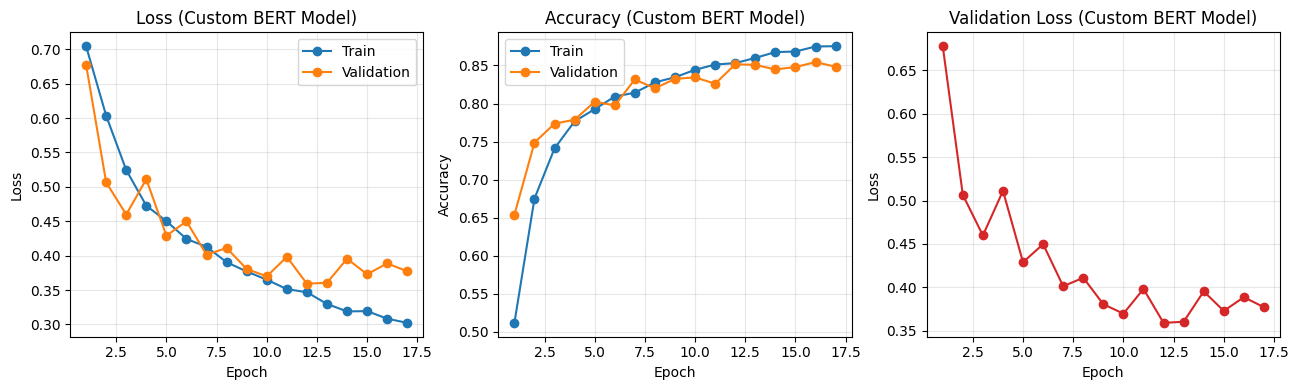

--- Resultats en el conjunt TEST ---

Test Loss: 0.3721
Test Accuracy: 0.8388
Temps d'inferència (conjunt de test complet): 17.43 s

Speedup respecte a l'exercici 4: 1.11x
El model és 1.11x més ràpid (es necessitava 5-10x)

TAULA DE RESULTATS
+-----------------------------+----------------+-----------------+-----------------------------------+
| Model                       | # Paràmetres   |   Accuracy test | Temps inferencia (test complet)   |
+=============================+================+=================+===================================+
| gaunernst/bert-mini-uncased | 11,171,074     |          0.8764 | 19.37 s                           |
+-----------------------------+----------------+-----------------+-----------------------------------+
| distilbert-base-uncased     | 14,177,282     |          0.9062 | 173.67 s                          |
| (frozen: 4/6)               |                |                 |                                   |
+-----------------------------+-----

In [14]:
print("=" * 70)
print("EXERCICI 6: DEFINICIÓ DEL MODEL PERSONALITZAT BASAT EN BERT")
print("=" * 70)

# Crear configuració del model
config_custom = CustomBertConfig(
    vocab_size=VOCAB_SIZE_CUSTOM,
    hidden_size=HIDDEN_SIZE_CUSTOM,
    num_attention_heads=NUM_ATTENTION_HEADS_CUSTOM,
    num_hidden_layers=NUM_HIDDEN_LAYERS_CUSTOM,
    intermediate_size=INTERMEDIATE_SIZE_CUSTOM,
    max_position_embeddings=MAX_LENGTH_CUSTOM,
    hidden_dropout_prob=DROPOUT_RATE_CUSTOM,
    num_labels=2,
)

# Crear el model
custom_model = CustomBertClassifier(config_custom).to(DEVICE)

# Comptar paràmetres
total_params_custom = sum(p.numel() for p in custom_model.parameters())
print(f"\nNombre total de paràmetres del model personalitzat: {total_params_custom:,}")

# Verificar que estem dins del rang requerit
assert (
    5_000_000 <= total_params_custom <= 6_500_000
), f"El model ha de tenir entre 5-6.5M paràmetres, però en té {total_params_custom:,}"

# ============================================================================
# PREPARAR DATALOADERS
# ============================================================================
train_ds_custom = train_ds
val_ds_custom = val_ds
test_ds_custom = test_ds

if DEBUG_SUBSET_CUSTOM:
    train_ds_custom = train_ds.select(range(min(DEBUG_TRAIN_CUSTOM, len(train_ds))))
    val_ds_custom = val_ds.select(range(min(DEBUG_VAL_CUSTOM, len(val_ds))))
    test_ds_custom = test_ds.select(range(min(DEBUG_TEST_CUSTOM, len(test_ds))))
    print("[DEBUG] S'estan utilitzant subconjunts reduïts.")

train_loader_custom = DataLoader(
    train_ds_custom, batch_size=BATCH_SIZE_CUSTOM, shuffle=False
)
val_loader_custom = DataLoader(
    val_ds_custom, batch_size=BATCH_SIZE_CUSTOM, shuffle=False
)
test_loader_custom = DataLoader(
    test_ds_custom, batch_size=BATCH_SIZE_CUSTOM, shuffle=False
)

# ============================================================================
# ENTRENAMENT
# ============================================================================
criterion_custom = nn.CrossEntropyLoss()
optimizer_custom = torch.optim.AdamW(
    custom_model.parameters(),
    lr=LR_CUSTOM,
    weight_decay=WEIGHT_DECAY_CUSTOM,
)


def run_epoch_custom(model, loader, optimizer=None):
    """
    Funció d'entrenament/avaluació per al model personalitzat.
    Parameters:
        model (nn.Module): model de classificació a entrenar o avaluar
        loader (DataLoader): DataLoader que proporciona les dades per a aquesta època
        optimizer (torch.optim.Optimizer, optional): optimitzador per actualitzar els pesos del model durant l'entrenament. Si és None, s'executa en mode avaluació sense actualitzar pesos.
    Returns:
        tuple[float, float]: pèrdua mitjana i accuracy mitjana per a aquesta època, calculades sobre totes les dades del loader.
    Aquesta funció gestiona l'entrenament o avaluació del model personalitzat segons si s'ha passat un optimitzador o no, i calcula la pèrdua mitjana i l'accuracy mitjana per a l'època.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion_custom(logits, labels)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = torch.argmax(logits, dim=1)
            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)
    avg_loss = total_loss / total_examples
    avg_acc = total_correct / total_examples
    return avg_loss, avg_acc


history_custom = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_state_custom = None
best_val_loss_custom = float("inf")
best_epoch_custom = 0
patience_counter_custom = 0

print("\n--- Entrenament del model personalitzat ---\n")

for epoch in range(1, NUM_EPOCHS_CUSTOM + 1):
    train_loss, train_acc = run_epoch_custom(
        custom_model, train_loader_custom, optimizer=optimizer_custom
    )
    val_loss, val_acc = run_epoch_custom(
        custom_model, val_loader_custom, optimizer=None
    )
    history_custom["train_loss"].append(train_loss)
    history_custom["val_loss"].append(val_loss)
    history_custom["train_acc"].append(train_acc)
    history_custom["val_acc"].append(val_acc)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS_CUSTOM} | "
        f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | Val acc: {val_acc:.4f}"
    )
    if val_loss < best_val_loss_custom:
        best_val_loss_custom = val_loss
        best_epoch_custom = epoch
        best_state_custom = {
            k: v.detach().cpu().clone() for k, v in custom_model.state_dict().items()
        }
        patience_counter_custom = 0
    else:
        patience_counter_custom += 1
        if patience_counter_custom >= EARLY_STOPPING_PATIENCE_CUSTOM:
            print(f"Early stopping a l'època {epoch}.")
            break


if best_state_custom is not None:
    custom_model.load_state_dict(best_state_custom)

print(
    f"\nMillor checkpoint: època {best_epoch_custom} (val_loss={best_val_loss_custom:.4f})"
)

# ============================================================================
# VISUALITZACIÓ DE CORBES
# ============================================================================
epochs_axis_custom = range(1, len(history_custom["train_loss"]) + 1)
plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs_axis_custom, history_custom["train_loss"], marker="o", label="Train")
plt.plot(epochs_axis_custom, history_custom["val_loss"], marker="o", label="Validation")
plt.title("Loss (Custom BERT Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs_axis_custom, history_custom["train_acc"], marker="o", label="Train")
plt.plot(epochs_axis_custom, history_custom["val_acc"], marker="o", label="Validation")
plt.title("Accuracy (Custom BERT Model)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs_axis_custom, history_custom["val_loss"], marker="o", color="tab:red")
plt.title("Validation Loss (Custom BERT Model)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# ============================================================================
# AVALUACIÓ FINAL EN TEST I MESURA DE TEMPS D'INFERÈNCIA
# ============================================================================
test_start_custom = time.time()
test_loss_custom, test_acc_custom = run_epoch_custom(
    custom_model, test_loader_custom, optimizer=None
)
test_inference_time_custom = time.time() - test_start_custom

print("--- Resultats en el conjunt TEST ---\n")
print(f"Test Loss: {test_loss_custom:.4f}")
print(f"Test Accuracy: {test_acc_custom:.4f}")
print(
    f"Temps d'inferència (conjunt de test complet): {test_inference_time_custom:.2f} s"
)

# Verificar que compleix el requisit de velocitat
speedup = test_inference_time / test_inference_time_custom
print(f"\nSpeedup respecte a l'exercici 4: {speedup:.2f}x")
if speedup < 5:
    print(f"El model és {speedup:.2f}x més ràpid (es necessitava 5-10x)")
else:
    print("El model compleix el requisit de velocitat (5-10x)")

# ============================================================================
# ACTUALITZAR TAULA DE RESULTATS
# ============================================================================
results_row_custom = [
    "Custom BERT (personalitzat)",
    f"{total_params_custom:,}",
    f"{test_acc_custom:.4f}",
    f"{test_inference_time_custom:.2f} s",
]
results_row_bert = globals().get("results_row_bert", ["N/A", "N/A", "N/A", "N/A"])
results_row_distil = globals().get("results_row_distil", ["N/A", "N/A", "N/A", "N/A"])
results_table = [
    results_row_bert,
    results_row_distil,
    results_row_custom,
]
print("\nTAULA DE RESULTATS")
print(
    tabulate(
        results_table,
        headers=[
            "Model",
            "# Paràmetres",
            "Accuracy test",
            "Temps inferencia (test complet)",
        ],
        tablefmt="grid",
    )
)

# Guardar checkpoints per reutilitzar el student a l'exercici 7
os.makedirs("checkpoints", exist_ok=True)
torch.save(
    {
        "epoch": best_epoch_custom,
        "model_state_dict": custom_model.state_dict(),
        "val_loss": best_val_loss_custom,
        "val_acc": history_custom["val_acc"][best_epoch_custom - 1],
        "config": {
            "vocab_size": VOCAB_SIZE_CUSTOM,
            "hidden_size": HIDDEN_SIZE_CUSTOM,
            "num_attention_heads": NUM_ATTENTION_HEADS_CUSTOM,
            "num_hidden_layers": NUM_HIDDEN_LAYERS_CUSTOM,
            "intermediate_size": INTERMEDIATE_SIZE_CUSTOM,
            "max_position_embeddings": MAX_LENGTH_CUSTOM,
            "hidden_dropout_prob": DROPOUT_RATE_CUSTOM,
            "attention_probs_dropout_prob": 0.1,
            "num_labels": 2,
        },
    },
    "checkpoints/custom_bert_best.pt",
)
torch.save(
    {
        "epoch": len(history_custom["train_loss"]),
        "model_state_dict": custom_model.state_dict(),
        "val_loss": history_custom["val_loss"][-1],
        "val_acc": history_custom["val_acc"][-1],
        "config": {
            "vocab_size": VOCAB_SIZE_CUSTOM,
            "hidden_size": HIDDEN_SIZE_CUSTOM,
            "num_attention_heads": NUM_ATTENTION_HEADS_CUSTOM,
            "num_hidden_layers": NUM_HIDDEN_LAYERS_CUSTOM,
            "intermediate_size": INTERMEDIATE_SIZE_CUSTOM,
            "max_position_embeddings": MAX_LENGTH_CUSTOM,
            "hidden_dropout_prob": DROPOUT_RATE_CUSTOM,
            "attention_probs_dropout_prob": 0.1,
            "num_labels": 2,
        },
    },
    "checkpoints/custom_bert_final.pt",
)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

<strong>Exercici 7. Knowledge Distillation [1,5 pts.].</strong>
El model de l'exercici 6 probablement pugui millorar-se si, en comptes d'aprendre de les dades, aprèn directament del model gran de l'exercici 5. Per fer-ho, pren el model gran de l'exercici 5 com a <i>teacher</i> (mestre) i el model de l'exercici 6 com a <i>student</i> (alumne). L'objectiu serà aplicar una tècnica de <strong>knowledge distillation</strong> (destil·lació de coneixement) de manera que el model <i>student</i>, en lloc d'aprendre a predir les etiquetes binàries de les dades, intenti aprendre els valors exactes de l'última capa del model <i>teacher</i>.
Revisa alguns enllaços per entendre millor com funciona un entrenament <i>teacher-student</i>:
<ul>
    <li><a href="https://www.ibm.com/think/topics/knowledge-distillation">IBM: Knowledge Distillation</a></li>
    <li><a href="https://labelyourdata.com/articles/machine-learning/knowledge-distillation">Label Your Data: Knowledge Distillation</a></li>
    <li><a href="https://docs.pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html">PyTorch: Knowledge Distillation Tutorial</a></li>
</ul>

Es demana:
<ol>
    <li>Munta un sistema d'entrenament <i>teacher-student</i>, on el model <i>teacher</i> és el de l'exercici 5 i el model <i>student</i> és el de l'exercici 6 (un cop ja entrenat a l'exercici 6).</li>
    <li>Entrena el model <i>student</i> (controlant de forma adequada el valor <strong>alpha</strong>) de manera que aprengui del model <i>teacher</i>. Mitjançant aquesta tècnica hauràs d'intentar que el model, que ja estava saturat en aprendre directament de les dades, sigui capaç d'aprendre del model <i>teacher</i> i continuar millorant l'<i>accuracy</i> sobre test.</li>
    <li>Mostra les corbes d'entrenament, test, etc.</li>
    <li>Actualitza la taula de resultats amb aquest model i mostra-la en pantalla.</li>
    <li>Fes una petita reflexió (3-4 línies) sobre els exercicis 4, 5, 6 i 7, assenyalant les teves conclusions, dificultats, avantatges, etc.</li>
</ol>

<strong>Nota:</strong> La complexitat del model <i>student</i> i la quantitat de dades és molt limitada, per la qual cosa pot ser difícil encertar amb l'estratègia de <i>distillation</i> adequada perquè el model <i>student</i> continuï aprenent. Si no ho aconseguissis, explica què has intentat a la teva reflexió.
</div>


EXERCICI 7: DESTIL·LACIÓ DE CONEIXEMENT
alpha = 0.6 | temperature = 4.0

--- Entrenament student amb destil·lació ---

Epoch 1/20 | Train loss: 0.4934 | Train acc: 0.8708 | Val loss: 0.5534 | Val acc: 0.8464
Epoch 2/20 | Train loss: 0.4709 | Train acc: 0.8729 | Val loss: 0.5546 | Val acc: 0.8472
Epoch 3/20 | Train loss: 0.4705 | Train acc: 0.8733 | Val loss: 0.5392 | Val acc: 0.8420
Epoch 4/20 | Train loss: 0.4661 | Train acc: 0.8727 | Val loss: 0.6216 | Val acc: 0.8416
Epoch 5/20 | Train loss: 0.4564 | Train acc: 0.8748 | Val loss: 0.5647 | Val acc: 0.8484
Epoch 6/20 | Train loss: 0.4482 | Train acc: 0.8778 | Val loss: 0.5530 | Val acc: 0.8528
Epoch 7/20 | Train loss: 0.4388 | Train acc: 0.8827 | Val loss: 0.5380 | Val acc: 0.8528
Epoch 8/20 | Train loss: 0.4297 | Train acc: 0.8825 | Val loss: 0.5552 | Val acc: 0.8488
Epoch 9/20 | Train loss: 0.4245 | Train acc: 0.8839 | Val loss: 0.5191 | Val acc: 0.8504
Epoch 10/20 | Train loss: 0.4178 | Train acc: 0.8850 | Val loss: 0.5415 | Val ac

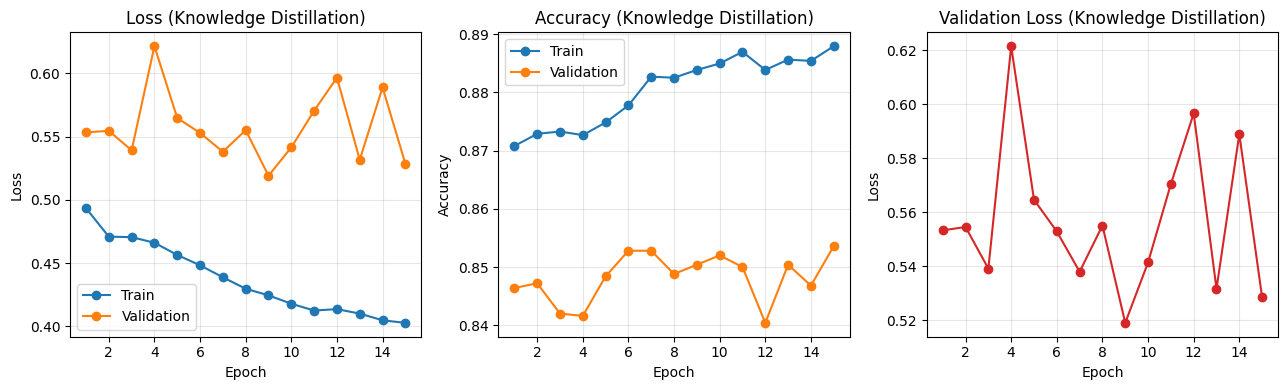


--- Resultats KD en el conjunt de TEST ---

Test Loss: 0.5232
Test Accuracy: 0.8412
Temps d'inferència (test complet): 189.63 s

Canvi d'accuracy respecte a l'exercici 6: +0.0024
Speedup/inferència respecte a l'exercici 6: 0.09x

TAULA DE RESULTATS
+-----------------------------+----------------+-----------------+-----------------------------------+
| Model                       | # Paràmetres   |   Accuracy test | Temps inferencia (test complet)   |
+=============================+================+=================+===================================+
| gaunernst/bert-mini-uncased | 11,171,074     |          0.8764 | 19.37 s                           |
+-----------------------------+----------------+-----------------+-----------------------------------+
| distilbert-base-uncased     | 14,177,282     |          0.9062 | 173.67 s                          |
| (frozen: 4/6)               |                |                 |                                   |
+----------------------------

In [15]:
# ============================================================================
# EXERCICI 7: DESTIL·LACIÓ DE CONEIXEMENT
# ============================================================================
MODEL_NAME_DISTIL = globals().get("MODEL_NAME_DISTIL", "distilbert-base-uncased")
DROPOUT_RATE_DISTIL = globals().get("DROPOUT_RATE_DISTIL", 0.4)

VOCAB_SIZE_CUSTOM = globals().get("VOCAB_SIZE_CUSTOM", 30522)
HIDDEN_SIZE_CUSTOM = globals().get("HIDDEN_SIZE_CUSTOM", 160)
NUM_ATTENTION_HEADS_CUSTOM = globals().get("NUM_ATTENTION_HEADS_CUSTOM", 4)
NUM_HIDDEN_LAYERS_CUSTOM = globals().get("NUM_HIDDEN_LAYERS_CUSTOM", 5)
INTERMEDIATE_SIZE_CUSTOM = globals().get("INTERMEDIATE_SIZE_CUSTOM", 640)
MAX_LENGTH_CUSTOM = globals().get("MAX_LENGTH_CUSTOM", 256)
DROPOUT_RATE_CUSTOM = globals().get("DROPOUT_RATE_CUSTOM", 0.3)
BATCH_SIZE_CUSTOM = globals().get("BATCH_SIZE_CUSTOM", 32)

# Temperatura més alta per suavitzar les distribucions de probabilitat del
# professor i facilitar l'aprenentatge del student. Valors típics estan entre 2
# i 5.
KD_TEMPERATURE = 4.0 # Abans era 2.5 
# Alpha per equilibrar la pèrdua de distil·lació i la pèrdua de classificació,
# on 0.5 significa que es dóna igual importància a ambdues. Es pot ajustar
# segons els resultats obtinguts. Valors típics estan entre 0.3 i 0.7. Els
# valors inferiors a 0.5 donen més pes a la pèrdua de classificació, mentre que
# els superiors a 0.5 donen més pes a la pèrdua de distil·lació.
KD_ALPHA = 0.6 # Abans era 0.55
KD_LR = 5e-5
KD_WEIGHT_DECAY = 0.005
KD_PATIENCE = 6
KD_EPOCHS = 20


def build_teacher_model() -> nn.Module:
    """
    Crea una nova instància del model professor. Aquesta funció es pot utilitzar per crear un model nou si no hi ha checkpoints disponibles, o per carregar un model des de checkpoints.
    Returns:
        nn.Module: nova instància del model professor.
    """
    if "DistilBertClassifier" not in globals():
        raise RuntimeError(
            "La classe DistilBertClassifier no està definida. Assegura't d'executar l'exercici 5 abans de l'exercici 7."
        )
    return DistilBertClassifier(
        model_name=MODEL_NAME_DISTIL, dropout_rate=DROPOUT_RATE_DISTIL
    ).to(DEVICE)


def build_student_model() -> nn.Module:
    """
    Crea una nova instància del model estudiant personalitzat. Aquesta funció es pot utilitzar per crear un model nou si no hi ha checkpoints disponibles, o per carregar un model des de checkpoints.
    Returns:
        nn.Module: nova instància del model estudiant personalitzat.
    """
    if "CustomBertClassifier" not in globals():
        raise RuntimeError(
            "La classe CustomBertClassifier no està definida. Assegura't d'executar l'exercici 6 abans de l'exercici 7."
        )
    config = CustomBertConfig(
        vocab_size=VOCAB_SIZE_CUSTOM,
        hidden_size=HIDDEN_SIZE_CUSTOM,
        num_attention_heads=NUM_ATTENTION_HEADS_CUSTOM,
        num_hidden_layers=NUM_HIDDEN_LAYERS_CUSTOM,
        intermediate_size=INTERMEDIATE_SIZE_CUSTOM,
        max_position_embeddings=MAX_LENGTH_CUSTOM,
        hidden_dropout_prob=DROPOUT_RATE_CUSTOM,
        attention_probs_dropout_prob=0.1,
        num_labels=2,
    )
    return CustomBertClassifier(config).to(DEVICE)


def load_teacher_model() -> nn.Module:
    """
    Carrega el model professor. Si ja existeix a la memòria global, el reutilitza. Si no, intenta carregar els checkpoints guardats de l'exercici 5. Si no hi ha checkpoints, crea un nou model.
    Returns:
        nn.Module: model professor carregat i preparat per a l'entrenament de knowledge distillation.
    """
    if "classification_model_distil" in globals():
        return classification_model_distil.to(DEVICE)
    ckpt_path = (
        "checkpoints/distilbert_frozen_best.pt"
        if os.path.exists("checkpoints/distilbert_frozen_best.pt")
        else "checkpoints/distilbert_frozen_final.pt"
    )
    if not os.path.exists(ckpt_path):
        raise RuntimeError(
            "No teacher model available. Run exercise 5 first or generate the DistilBERT checkpoints."
        )

    model = build_teacher_model()
    teacher_ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(teacher_ckpt["model_state_dict"], strict=False)
    return model


def load_student_model() -> nn.Module:
    """
    Carrega el model estudiant personalitzat. Si ja existeix a la memòria global, el reutilitza. Si no, intenta carregar els checkpoints guardats de l'exercici 6. Si no hi ha checkpoints, crea un nou model.
    Returns:
        nn.Module: model estudiant carregat i preparat per a l'entrenament de knowledge distillation.
    """
    if "custom_model" in globals():
        model = custom_model.to(DEVICE)
    else:
        ckpt_path = (
            "checkpoints/custom_bert_best.pt"
            if os.path.exists("checkpoints/custom_bert_best.pt")
            else "checkpoints/custom_bert_final.pt"
        )
        if not os.path.exists(ckpt_path):
            raise RuntimeError(
                "No student model available. Run exercise 6 first or generate the custom BERT checkpoints."
            )
        model = build_student_model()
        student_ckpt = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(student_ckpt["model_state_dict"], strict=False)

    if "best_state_custom" in globals() and best_state_custom is not None:
        model.load_state_dict(best_state_custom)
    return model


print("=" * 80)
print("EXERCICI 7: DESTIL·LACIÓ DE CONEIXEMENT")
print("=" * 80)
print(f"alpha = {KD_ALPHA} | temperature = {KD_TEMPERATURE}")

teacher_model = load_teacher_model()
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False

student_model = load_student_model()

kd_batch_size = BATCH_SIZE_CUSTOM if "BATCH_SIZE_CUSTOM" in globals() else 32
kd_train_source = train_ds_custom if "train_ds_custom" in globals() else train_ds
kd_val_source = val_ds_custom if "val_ds_custom" in globals() else val_ds
kd_test_source = test_ds_custom if "test_ds_custom" in globals() else test_ds

kd_train_loader = DataLoader(kd_train_source, batch_size=kd_batch_size, shuffle=True)
kd_val_loader = DataLoader(kd_val_source, batch_size=kd_batch_size, shuffle=False)
kd_test_loader = DataLoader(kd_test_source, batch_size=kd_batch_size, shuffle=False)

kd_optimizer = torch.optim.AdamW(
    student_model.parameters(), lr=KD_LR, weight_decay=KD_WEIGHT_DECAY
)
criterion_kd = nn.CrossEntropyLoss()


def distillation_loss(
    student_logits: torch.Tensor, teacher_logits: torch.Tensor, labels: torch.Tensor
) -> torch.Tensor:
    """
    Calcula la pèrdua de destil·lació combinada entre la pèrdua dura i la pèrdua suau.
    Parameters:
        student_logits (torch.Tensor): logits del model estudiant
        teacher_logits (torch.Tensor): logits del model professor
        labels (torch.Tensor): etiquetes reals per al càlcul de la pèrdua dura
    Returns:
        torch.Tensor: pèrdua de destil·lació combinada
    """
    hard_loss = criterion_kd(student_logits, labels)
    soft_targets = F.softmax(teacher_logits / KD_TEMPERATURE, dim=1)
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / KD_TEMPERATURE, dim=1),
        soft_targets,
        reduction="batchmean",
    ) * (KD_TEMPERATURE**2)
    return KD_ALPHA * soft_loss + (1.0 - KD_ALPHA) * hard_loss


def run_epoch_kd(
    student: torch.nn.Module,
    teacher: torch.nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer = None,
) -> tuple[float, float]:
    """
    Funció d'entrenament/avaluació per al procés de knowledge destil·lació.
    Parameters:
        student (torch.nn.Module): model estudiant que s'està entrenant o avaluant
        teacher (torch.nn.Module): model professor que proporciona les prediccions "suaus" per a la destil·lació
        loader (DataLoader): DataLoader que proporciona les dades per a aquesta època
        optimizer (torch.optim.Optimizer, optional): optimitzador per actualitzar els pesos del model estudiant durant l'entrenament.
    Returns:
        tuple[float, float]: (loss, accuracy) per a aquesta època
    Si es passa un optimitzador, la funció realitza una època d'entrenament actualitzant els pesos del model estudiant. Si no es passa un optimitzador, la funció realitza una avaluació sense actualitzar pesos. En ambdós casos, es calcula la pèrdua de destil·lació combinada i l'accuracy del model estudiant.
    """
    is_train = optimizer is not None
    student.train() if is_train else student.eval()
    teacher.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.set_grad_enabled(is_train):
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)

            with torch.no_grad():
                teacher_logits = teacher(
                    input_ids=input_ids, attention_mask=attention_mask
                )

            student_logits = student(input_ids=input_ids, attention_mask=attention_mask)
            loss = distillation_loss(student_logits, teacher_logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
                optimizer.step()

            preds = torch.argmax(student_logits, dim=1)
            total_loss += loss.item() * labels.size(0)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples


history_kd = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_state_kd = None
best_val_loss_kd = float("inf")
best_epoch_kd = 0
patience_counter_kd = 0

print("\n--- Entrenament student amb destil·lació ---\n")

for epoch in range(1, KD_EPOCHS + 1):
    train_loss_kd, train_acc_kd = run_epoch_kd(
        student_model, teacher_model, kd_train_loader, optimizer=kd_optimizer
    )
    val_loss_kd, val_acc_kd = run_epoch_kd(
        student_model, teacher_model, kd_val_loader, optimizer=None
    )

    history_kd["train_loss"].append(train_loss_kd)
    history_kd["val_loss"].append(val_loss_kd)
    history_kd["train_acc"].append(train_acc_kd)
    history_kd["val_acc"].append(val_acc_kd)

    print(
        f"Epoch {epoch}/{KD_EPOCHS} | Train loss: {train_loss_kd:.4f} | Train acc: {train_acc_kd:.4f} | "
        f"Val loss: {val_loss_kd:.4f} | Val acc: {val_acc_kd:.4f}"
    )

    if val_loss_kd < best_val_loss_kd:
        best_val_loss_kd = val_loss_kd
        best_epoch_kd = epoch
        best_state_kd = {
            k: v.detach().cpu().clone() for k, v in student_model.state_dict().items()
        }
        patience_counter_kd = 0
    else:
        patience_counter_kd += 1
        if patience_counter_kd >= KD_PATIENCE:
            print(f"Early stopping a l'època {epoch}.")
            break

if best_state_kd is not None:
    student_model.load_state_dict(best_state_kd)

os.makedirs("checkpoints", exist_ok=True)
torch.save(
    {
        "epoch": best_epoch_kd,
        "model_state_dict": student_model.state_dict(),
        "val_loss": best_val_loss_kd,
        "alpha": KD_ALPHA,
        "temperature": KD_TEMPERATURE,
    },
    "checkpoints/custom_kd_best.pt",
)
torch.save(
    {
        "epoch": len(history_kd["train_loss"]),
        "model_state_dict": student_model.state_dict(),
        "val_loss": history_kd["val_loss"][-1],
        "alpha": KD_ALPHA,
        "temperature": KD_TEMPERATURE,
    },
    "checkpoints/custom_kd_final.pt",
)

print(
    f"\nMillor checkpoint KD: època {best_epoch_kd} (val_loss={best_val_loss_kd:.4f})"
)

kd_epochs_axis = range(1, len(history_kd["train_loss"]) + 1)
plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(kd_epochs_axis, history_kd["train_loss"], marker="o", label="Train")
plt.plot(kd_epochs_axis, history_kd["val_loss"], marker="o", label="Validation")
plt.title("Loss (Knowledge Distillation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(kd_epochs_axis, history_kd["train_acc"], marker="o", label="Train")
plt.plot(kd_epochs_axis, history_kd["val_acc"], marker="o", label="Validation")
plt.title("Accuracy (Knowledge Distillation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(kd_epochs_axis, history_kd["val_loss"], marker="o", color="tab:red")
plt.title("Validation Loss (Knowledge Distillation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

test_start_kd = time.time()
test_loss_kd, test_acc_kd = run_epoch_kd(
    student_model, teacher_model, kd_test_loader, optimizer=None
)
test_inference_time_kd = time.time() - test_start_kd

print("\n--- Resultats KD en el conjunt de TEST ---\n")
print(f"Test Loss: {test_loss_kd:.4f}")
print(f"Test Accuracy: {test_acc_kd:.4f}")
print(f"Temps d'inferència (test complet): {test_inference_time_kd:.2f} s")

kd_speedup_vs_ex6 = test_inference_time_custom / test_inference_time_kd
print(
    f"\nCanvi d'accuracy respecte a l'exercici 6: {test_acc_kd - test_acc_custom:+.4f}"
)
print(f"Speedup/inferència respecte a l'exercici 6: {kd_speedup_vs_ex6:.2f}x")

results_row_kd = [
    "Custom BERT + KD",
    f"{total_params_custom:,}",
    f"{test_acc_kd:.4f}",
    f"{test_inference_time_kd:.2f} s",
]
results_row_bert = globals().get("results_row_bert", ["N/A", "N/A", "N/A", "N/A"])
results_row_distil = globals().get("results_row_distil", ["N/A", "N/A", "N/A", "N/A"])
results_row_custom = globals().get("results_row_custom", ["N/A", "N/A", "N/A", "N/A"])
results_table = [
    results_row_bert,
    results_row_distil,
    results_row_custom,
    results_row_kd,
]
print("\nTAULA DE RESULTATS")
print(
    tabulate(
        results_table,
        headers=[
            "Model",
            "# Paràmetres",
            "Accuracy test",
            "Temps inferencia (test complet)",
        ],
        tablefmt="grid",
    )
)

La destil·lació ha millorat el model personalitzat en accuracy transferint coneixement de teacher (DistilBERT) a student (Custom BERT), demostrant que fins i tot amb datasets limitats i arquitectures petites, la tècnica és efectiva com a mecanisme de regularització i transfer learning.

### Resum dels exercicis 4, 5, 6 i 7

| Exercici | Descripció breu | Avantatges | Dificultats |
| -------- | --------------- | ---------- | ----------- |
| 4 | Finetuning downstream d'un model petit | Aquest exercici destaca per oferir un bon equilibri entre precisió i eficiència: permet assolir una accuracy superior als models seqüencials simples, amb un temps d'entrenament moderat, un nombre de paràmetres raonable (la majoria entrenables) i un temps d'inferència acceptable per a aplicacions reals. | La principal dificultat va ser trobar la taxa d'aprenentatge (learning rate) i el punt de dropout que equilibrin aprenentatge i regularització; valors massa grans del learning rate provoquen divergència mentre que valors massa petits retardaran la convergència, i un dropout inadequat pot degradar la capacitat de generalització o impedir l'aprenentatge suficient. |
| 5 | Finetuning downstream d'un model gran congelant capes | Aquest exercici aporta l'avantatge d'augmentar l'accuracy utilitzant un model més complex amb el mateix nombre de paràmetres entrenables ja que congelem la capa embedding i les primeres N capes. | Com congelar els paràmetres de cada capa i l'elecció dels hiperparàmetres. |
| 6 | Model personalitzat | Aquest exercici és interessant per la seva lleugeresa: amb pocs paràmetres entrenables ofereix temps d'entrenament i inferència reduïts encara que la seva accuracy acostuma a ser inferior. | La dificultat principal va ser trobar una configuració adequada per al model per complir els requisits, com ara el nombre de paràmetres i l'speedup. |
| 7 | Knowledge Distillation | Permet combinar models i augmentar l'accuracy. En la depuració el valor de l'augment de l'accuracy va ser més elevat. | Com recuperar i carregar els models dels exercicis anteriors utilitzant checkpoints. Funció de càlcul de Loss. Trobar quins són els valors més adequats per a alpha i temperatura. |

## Fonts

Fonts utilitzades en l'elaboració de la PAC (incloent-hi eines d'IA generativa).

**Fonts utilitzades en l'exercici 1 (Preparació de dades i tokenització)**

- [Dataset Wikitext-2 a Hugging Face](https://huggingface.co/datasets/Salesforce/wikitext) — Dataset utilitzat per a l'entrenament  
- [Guia completa sobre tokenització per a LLMs](https://www.traceloop.com/blog/a-comprehensive-guide-to-tokenizing-text-for-llms) — Explicació dels conceptes de tokenització  
- [Resum de tokenitzadors a Hugging Face](https://huggingface.co/docs/transformers/tokenizer_summary) — Documentació oficial sobre tokenitzadors

**Fonts utilitzades en l'exercici 2 (LSTM vs Transformer)**

- [Documentació PyTorch LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html) — Referència oficial del mòdul LSTM
- [Attention Is All You Need (Vaswani et al., 2017)](https://arxiv.org/pdf/1706.03762) — Paper original dels Transformers
- [Documentació PyTorch: MultiheadAttention](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) — Implementació d’atenció multi-cap

**Fonts utilitzades en l'exercici 3 (Anàlisi de matriu d'atenció)**

- [Documentació PyTorch: TransformerEncoder](https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html) — Codificador Transformer
- [Documentació PyTorch: MultiheadAttention](https://pytorch.org/docs/stable/generated/torch.nn.MultiheadAttention.html) — Com obtenir `attn_output_weights`
- [Documentació Hugging Face: Model outputs](https://huggingface.co/docs/transformers/main_classes/output) — Com recuperar `attentions` amb `output_attentions=True`
- [BertViz (GitHub)](https://github.com/jessevig/bertviz) — Visualitzador interactiu d’atenció amb arcs per unir paraules
- [BertViz (demo notebook)](https://colab.research.google.com/drive/1hXIQ77A4TYS4y3UthWF-Ci7V7vVUoxmQ?usp=sharing) — Exemple amb codi per visualitzar capes i caps d’atenció
- [Seaborn Heatmap](https://seaborn.pydata.org/generated/seaborn.heatmap.html) — Crear matrius d’atenció com a heatmap
- [Matplotlib imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) — Alternativa per dibuixar la matriu d’atenció
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/) — Explicació visual del mecanisme d'atenció

**Fonts utilitzades en l'exercici 4 (Fine-tuning BERT mini)**

- [Model BERT-mini a Hugging Face](https://huggingface.co/gaunernst/bert-mini-uncased) — Model preentrenat utilitzat
- [Dataset IMDB a Hugging Face](https://huggingface.co/datasets/stanfordnlp/imdb) — Dataset de classificació de sentiment
- [BERT: Pre-training of Deep Bidirectional Transformers (Devlin et al., 2018)](https://arxiv.org/pdf/1810.04805) — Paper original de BERT
- [Tutorial Hugging Face: Fine-tuning de models](https://huggingface.co/docs/transformers/training) — Guia oficial de fine-tuning
- [Tutorial PyTorch: Fine-tuning de models](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html) — Estratègies de fine-tuning

**Fonts utilitzades en l'exercici 5 (Fine-tuning BERT amb congelació de capes)**

- [Documentació Hugging Face: Estratègies d'entrenament](https://huggingface.co/docs/transformers/training) — Transfer learning i fine-tuning
- [Medium: Congelació de paràmetres](https://medium.com/@prabhatzade/freezing-layers-and-fine-tuning-transformer-models-in-pytorch-a-simple-guide-119cad0980c6) — Com congelar capes en PyTorch
- [BERT: Pre-training of Deep Bidirectional Transformers](https://arxiv.org/pdf/1810.04805) — Arquitectura i estratègies de fine-tuning
- [Exemples Hugging Face: Fine-tuning](https://github.com/huggingface/transformers/tree/main/examples)

**Fonts utilitzades en l'exercici 6 (Model personalitzat petit)**

- [Kaggle: Face BERT with custom classifier](https://www.kaggle.com/code/angyalfold/hugging-face-bert-with-custom-classifier-pytorch) - Classificador personalitzat en PyTorch

**Fonts utilitzades en l'exercici 7 (Knowledge Distillation)**

- [Guia: Knowledge Distillation](https://docs.pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html) — Explicació detallada de la tècnica
